In [ ]:
import requests
import pandas as pd
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB as Naive_Bayes
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_classification
from sklearn.metrics import ConfusionMatrixDisplay
from xgboost import XGBClassifier
import joblib

from IPython.display import display

# Data Collection
---
**Dataset Used :** Parkinsons Disease Dataset

**Dataset Source :** UCI Machine Learning Repository

**Dataset Hosting URL :** https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/parkinsons.data

In [ ]:
df = pd.read_csv("Parkinsons_data.csv")

In [ ]:
df.head()

,name,MDVP:Fo,MDVP:Fhi,MDVP:Flo,MDVP:Jitter,MDVP:Jitter.1,MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


# Data Preprocessing
Following steps will be performed on the dataset:




*   Dropping Redudant Columns
*   Checking For Duplicated Rows
*   Checking For Missing Values



In [ ]:
#checking dataset content
df.head()

,name,MDVP:Fo,MDVP:Fhi,MDVP:Flo,MDVP:Jitter,MDVP:Jitter.1,MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [ ]:
df.tail()

,name,MDVP:Fo,MDVP:Fhi,MDVP:Flo,MDVP:Jitter,MDVP:Jitter.1,MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
190,phon_R01_S50_2,174.188,230.978,94.261,0.00459,0.00003,0.00263,0.00259,0.00790,0.04087,...,0.07008,0.02764,19.517,0,0.448439,0.657899,-6.538586,0.121952,2.657476,0.133050
191,phon_R01_S50_3,209.516,253.017,89.488,0.00564,0.00003,0.00331,0.00292,0.00994,0.02751,...,0.04812,0.01810,19.147,0,0.431674,0.683244,-6.195325,0.129303,2.784312,0.168895
192,phon_R01_S50_4,174.688,240.005,74.287,0.01360,0.00008,0.00624,0.00564,0.01873,0.02308,...,0.03804,0.10715,17.883,0,0.407567,0.655683,-6.787197,0.158453,2.679772,0.131728
193,phon_R01_S50_5,198.764,396.961,74.904,0.00740,0.00004,0.00370,0.00390,0.01109,0.02296,...,0.03794,0.07223,19.020,0,0.451221,0.643956,-6.744577,0.207454,2.138608,0.123306
194,phon_R01_S50_6,214.289,260.277,77.973,0.00567,0.00003,0.00295,0.00317,0.00885,0.01884,...,0.03078,0.04398,21.209,0,0.462803,0.664357,-5.724056,0.190667,2.555477,0.148569


In [ ]:
print('Number of Features In Dataset :', df.shape[1])
print('Number of Instances In Dataset : ', df.shape[0])

Number of Features In Dataset : 24
Number of Instances In Dataset :  195


We will be dropping **"name"** column as it will have no use in training our model and infact the model can get confused because there are multiple recordings of the same person.

So we have 22 feature columns and we will be using that to predict the **"status"** column which will be our target column

In [ ]:
# Dropping the name column
df.drop(["name"], axis = 1, inplace = True)
# axis =1 drops the column, axis =0 is for rows.
# inplace = True will update our df

In [ ]:
# Exploring Information About Dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   MDVP:Fo         195 non-null    float64
 1   MDVP:Fhi        195 non-null    float64
 2   MDVP:Flo        195 non-null    float64
 3   MDVP:Jitter     195 non-null    float64
 4   MDVP:Jitter.1   195 non-null    float64
 5   MDVP:RAP        195 non-null    float64
 6   MDVP:PPQ        195 non-null    float64
 7   Jitter:DDP      195 non-null    float64
 8   MDVP:Shimmer    195 non-null    float64
 9   MDVP:Shimmer.1  195 non-null    float64
 10  Shimmer:APQ3    195 non-null    float64
 11  Shimmer:APQ5    195 non-null    float64
 12  MDVP:APQ        195 non-null    float64
 13  Shimmer:DDA     195 non-null    float64
 14  NHR             195 non-null    float64
 15  HNR             195 non-null    float64
 16  status          195 non-null    int64  
 17  RPDE            195 non-null    flo

In [ ]:
df.describe()

,MDVP:Fo,MDVP:Fhi,MDVP:Flo,MDVP:Jitter,MDVP:Jitter.1,MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer.1,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


Note -

Changing **status** column from int64 to bool

In [ ]:
df['status'] = df['status'].astype('bool')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   MDVP:Fo         195 non-null    float64
 1   MDVP:Fhi        195 non-null    float64
 2   MDVP:Flo        195 non-null    float64
 3   MDVP:Jitter     195 non-null    float64
 4   MDVP:Jitter.1   195 non-null    float64
 5   MDVP:RAP        195 non-null    float64
 6   MDVP:PPQ        195 non-null    float64
 7   Jitter:DDP      195 non-null    float64
 8   MDVP:Shimmer    195 non-null    float64
 9   MDVP:Shimmer.1  195 non-null    float64
 10  Shimmer:APQ3    195 non-null    float64
 11  Shimmer:APQ5    195 non-null    float64
 12  MDVP:APQ        195 non-null    float64
 13  Shimmer:DDA     195 non-null    float64
 14  NHR             195 non-null    float64
 15  HNR             195 non-null    float64
 16  status          195 non-null    bool   
 17  RPDE            195 non-null    flo

changing **status** from int64 to bool saved only 1.4kb because we only have 195 rows but in a big enough dataset it can save a lot of memory.

In [ ]:
# Checking For Duplicate Rows In Dataset
print("Number of duplicated rows are:",df.duplicated().sum())

Number of duplicated rows are: 0


The dataset does not contain any duplicated rows

In [ ]:
df.isna().sum()

,0
MDVP:Fo,0
MDVP:Fhi,0
MDVP:Flo,0
MDVP:Jitter,0
MDVP:Jitter.1,0
MDVP:RAP,0
MDVP:PPQ,0
Jitter:DDP,0
MDVP:Shimmer,0
MDVP:Shimmer.1,0


As seen above in the dataset, **no columns** have any NULL values

# **Exploratry Data Analysis**

<Axes: xlabel='status', ylabel='count'>

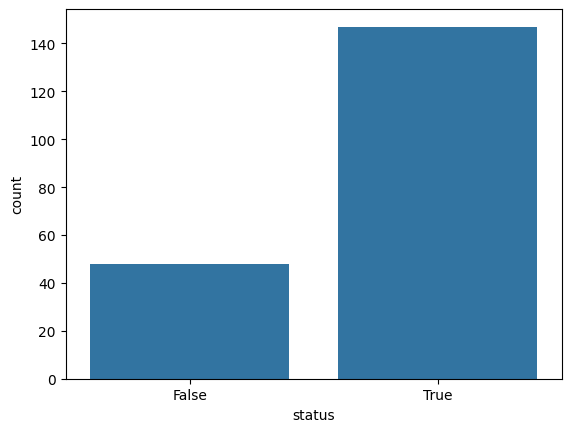

In [ ]:
#Balance of Data
sns.countplot(x='status',data=df)

In [ ]:
print(df['status'].value_counts())

status
True     147
False     48
Name: count, dtype: int64


So here we can see the dataset has 147 patients with the disease and 48 healthy one's. This is very imbalanced and after some further exploration we will try to balance this

<Axes: >

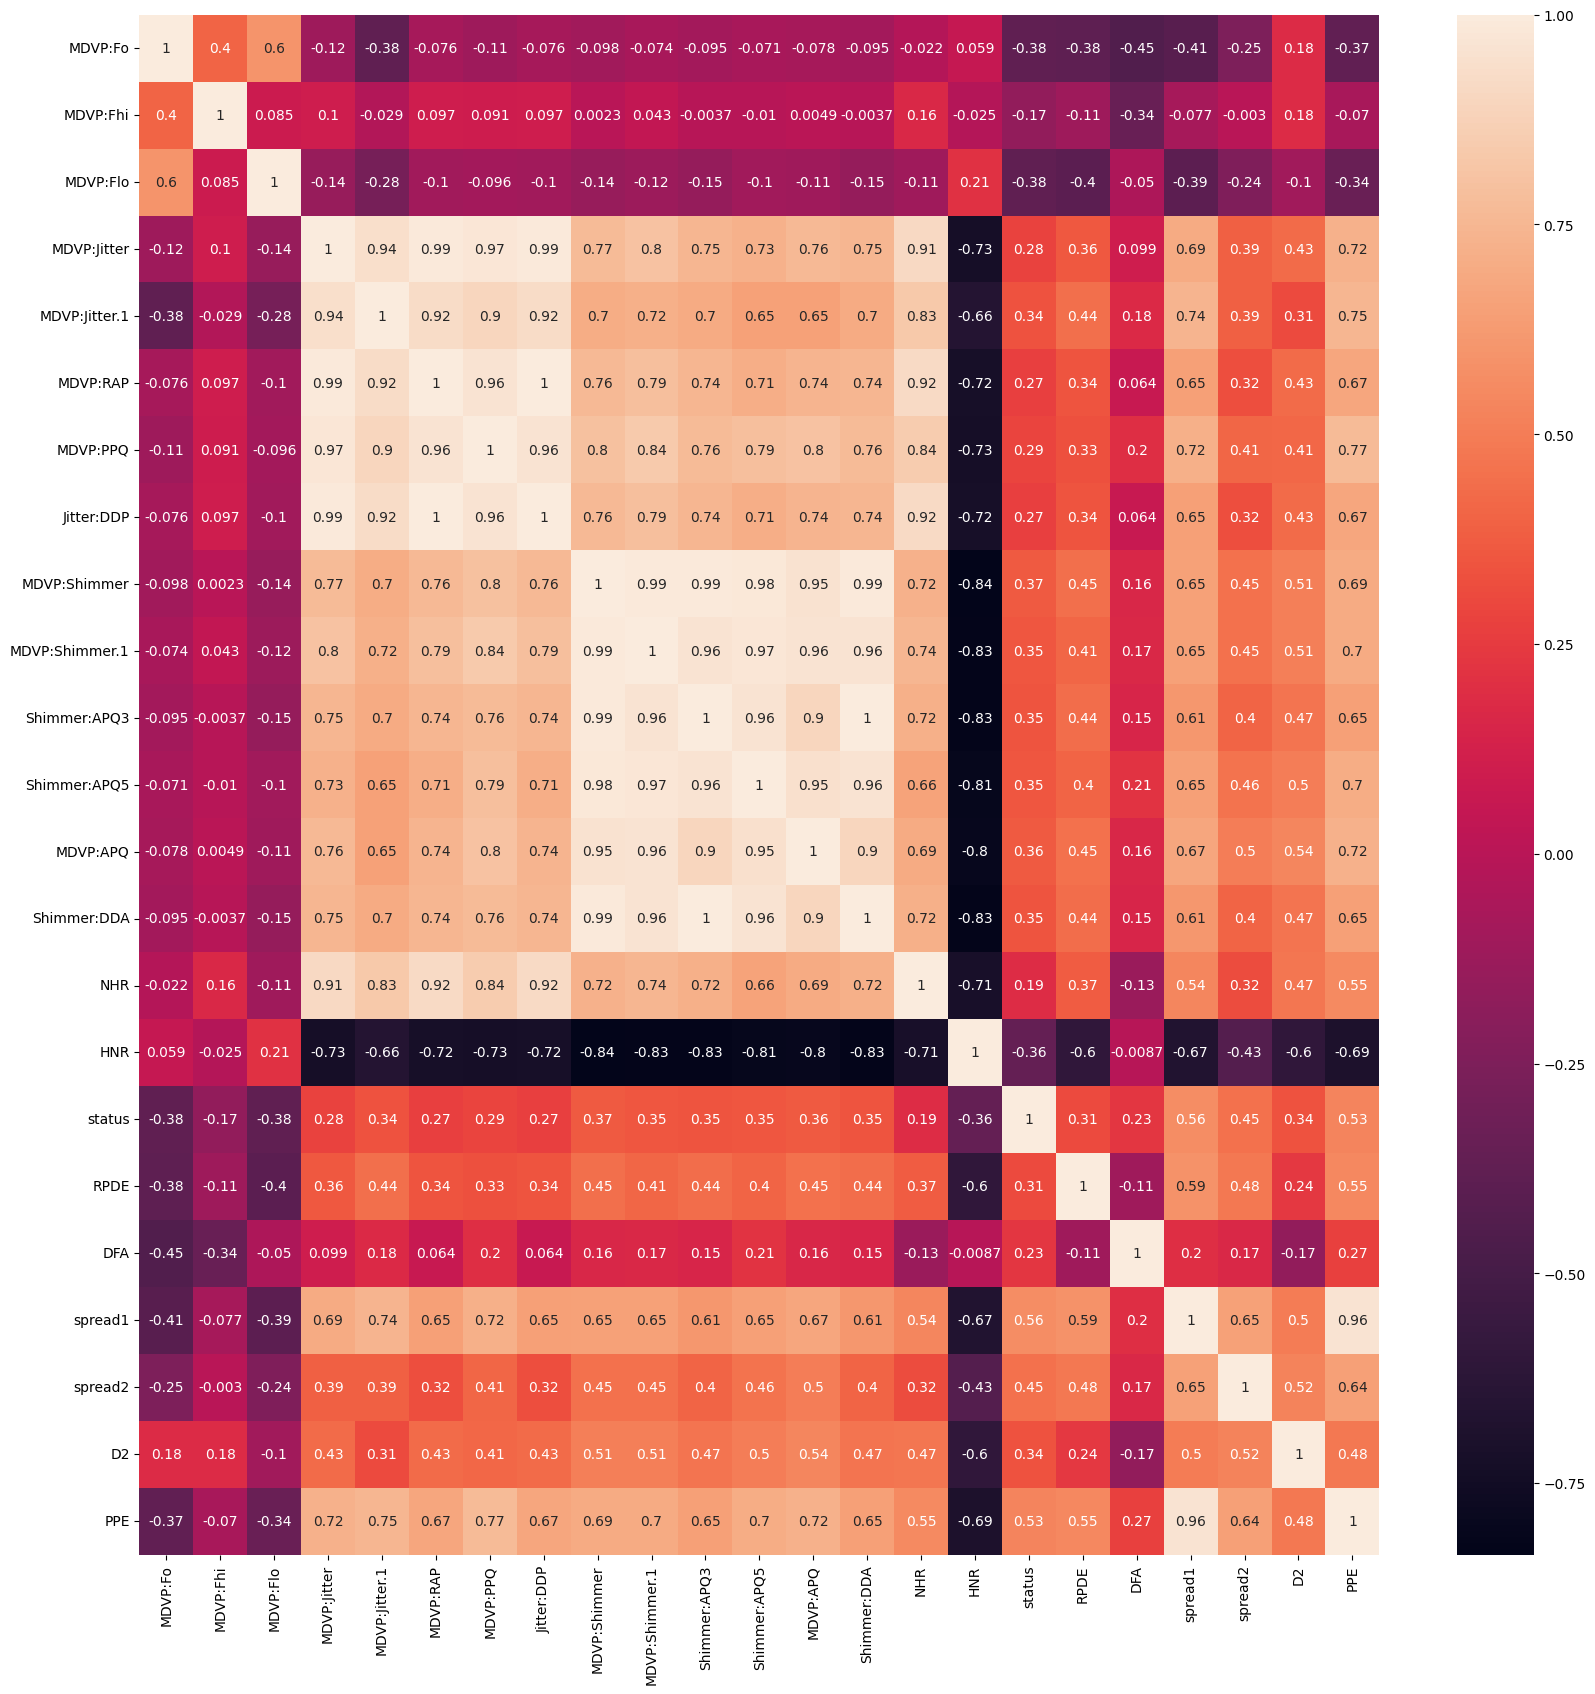

In [ ]:
fig, ax = plt.subplots(figsize=(20,20))
#fig controls the canvas(background) and ax controls the graph(plot)
#fig.patch.set_color("black")
sns.heatmap(df.corr(),annot=True,ax=ax)
#annot puts the values in the boxes, df.corr applies the correlation method to df
#ax=ax tells sns to plot it on ax area and not on any other canvas if present.

In this correlation heatmap, we can see that many independent features are highly correlated with eachother which is not a good thing because model will not be able to understand which column or feature is important. changes in 1 column will lead to overall change in prediction as they are highly correlated and model will not be able to distinguish.


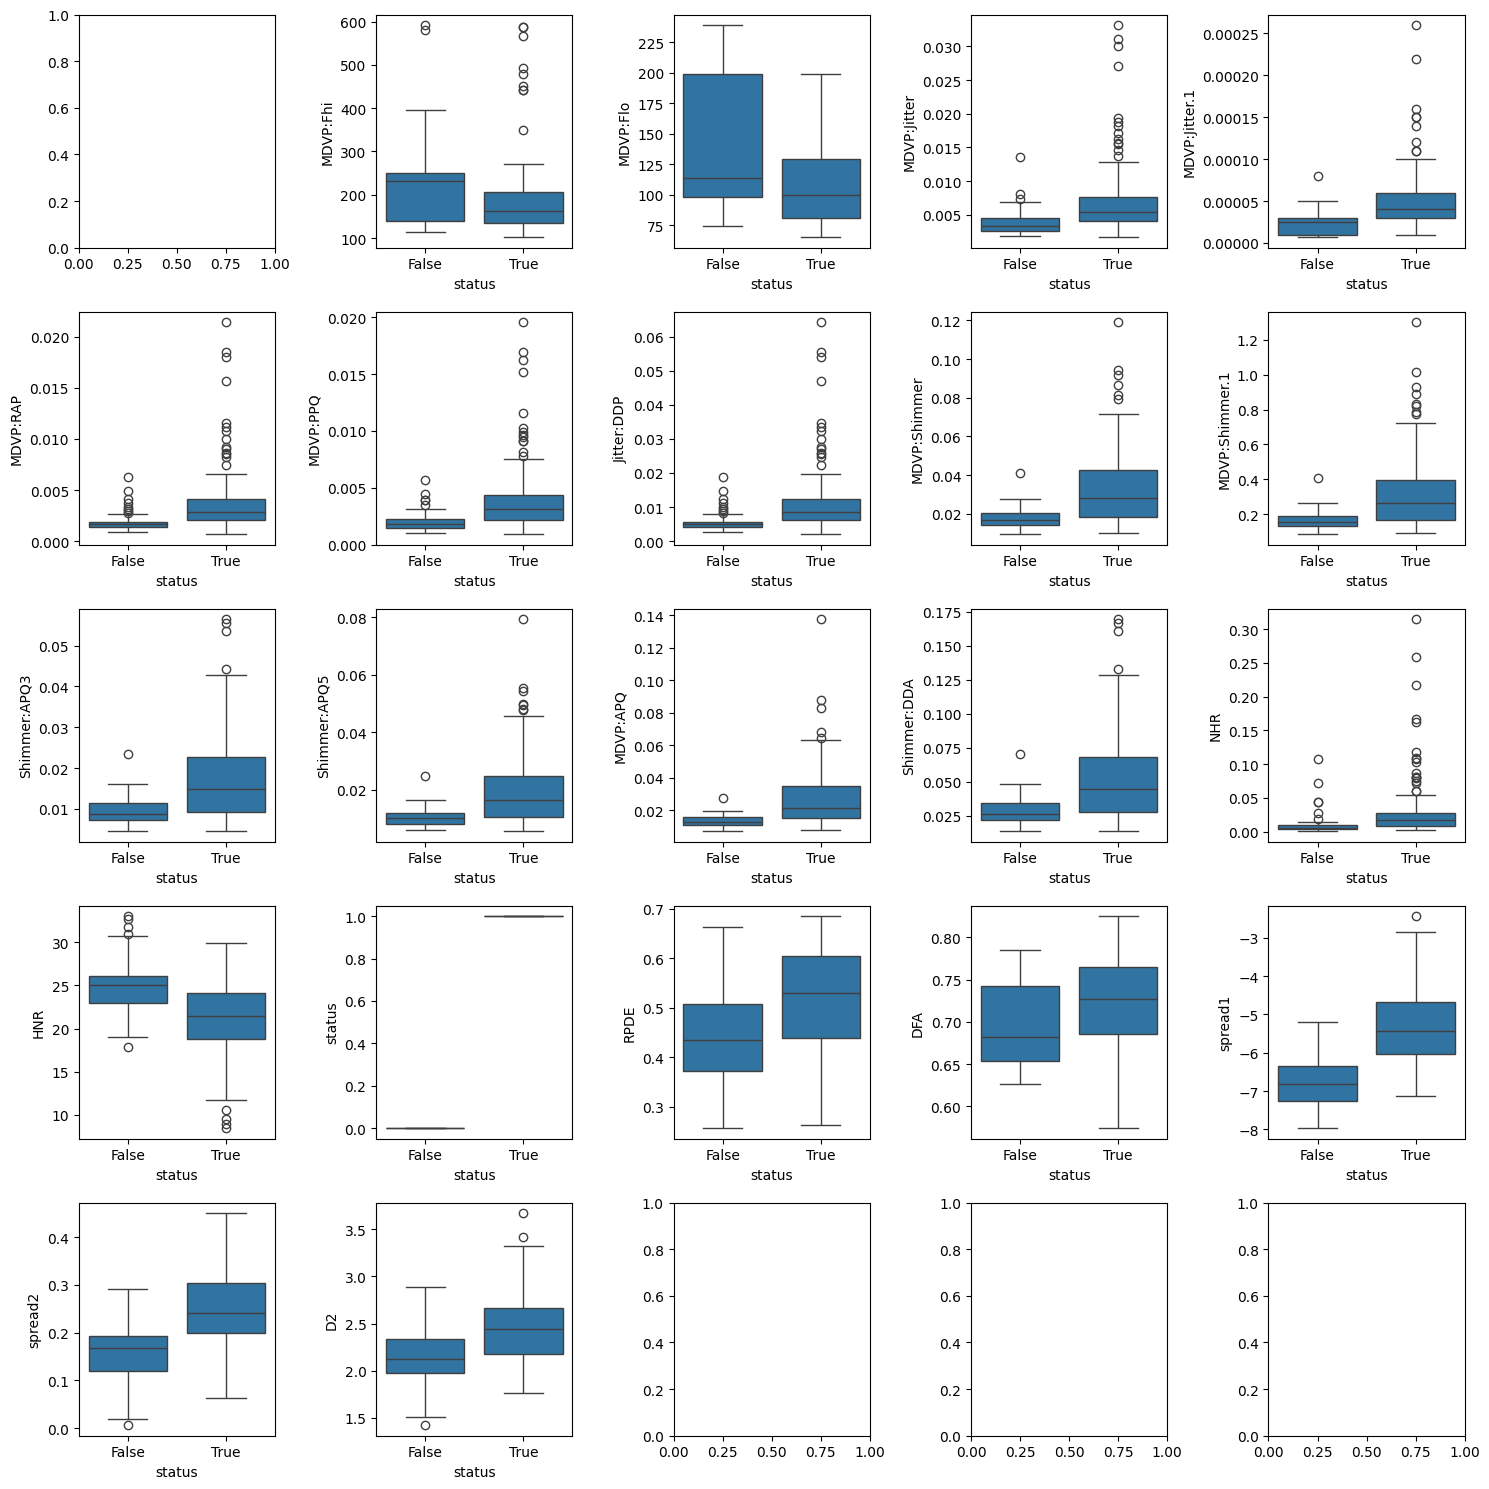

In [ ]:
#box plot
fig, axes = plt.subplots(5,5, figsize=(15,15))
axes = axes.flatten()
#axes.flatten changes the data into 1d array for easier looping.
#without it, it would be a 2d array where we would need to account for rows and columns to loop through it.
for i in range(1, len(df.columns)-1):
  sns.boxplot(x='status',y=df.iloc[:,i], data=df, orient = 'v', ax=axes[i])
plt.tight_layout()
plt.show()

From the boxplot shown above it is very evident that if a patient has a lower rate of 'HNR','MDVP:Flo(Hz)','MDVP:Fhi(Hz)','MDVP:Fo(Hz)' ,then he/she is affected by parkinsons disease.


**Balancing The Dataset**

In this section, as it is observed that the Dataset Is Heavily Imbalanced, with Number of Samples of Parkinson Disease Samples being 147, and Non-Parkinson Being only 48. Hence, in this section, we make use of SMOTE to Oversample and Balance the dataset

In [ ]:
# Exploring Imbalance In Dataset
df['status'].value_counts()

,count
status,
True,147
False,48


In [ ]:
# Extracting Features Into Features & Target
X = df.drop(['status'], axis=1)
y = df['status']

print('Feature (X) Shape Before Balancing :', X.shape)
print('Target (y) Shape Before Balancing :', y.shape)

Feature (X) Shape Before Balancing : (195, 22)
Target (y) Shape Before Balancing : (195,)


In [ ]:
# Intialising SMOTE Object
sm = SMOTE(random_state=300)

In [ ]:
# Resampling Data
X, y = sm.fit_resample(X, y)

In [ ]:
print('Feature (X) Shape After Balancing :', X.shape)
print('Target (y) Shape After Balancing :', y.shape)

Feature (X) Shape After Balancing : (294, 22)
Target (y) Shape After Balancing : (294,)


In [ ]:
# Scaling features between -1 and 1  for normalization
scaler = MinMaxScaler((-1,1))

In [ ]:
# define X_features , Y_labels
X_features = scaler.fit_transform(X)
Y_labels = y

In [ ]:
# splitting the dataset into traning and testing sets into 80 - 20
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X_features, Y_labels , test_size=0.20, random_state=20)

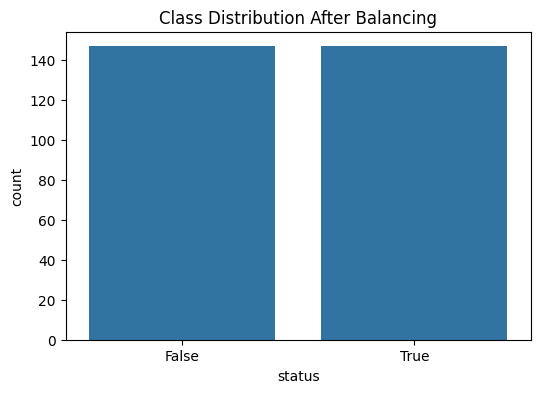

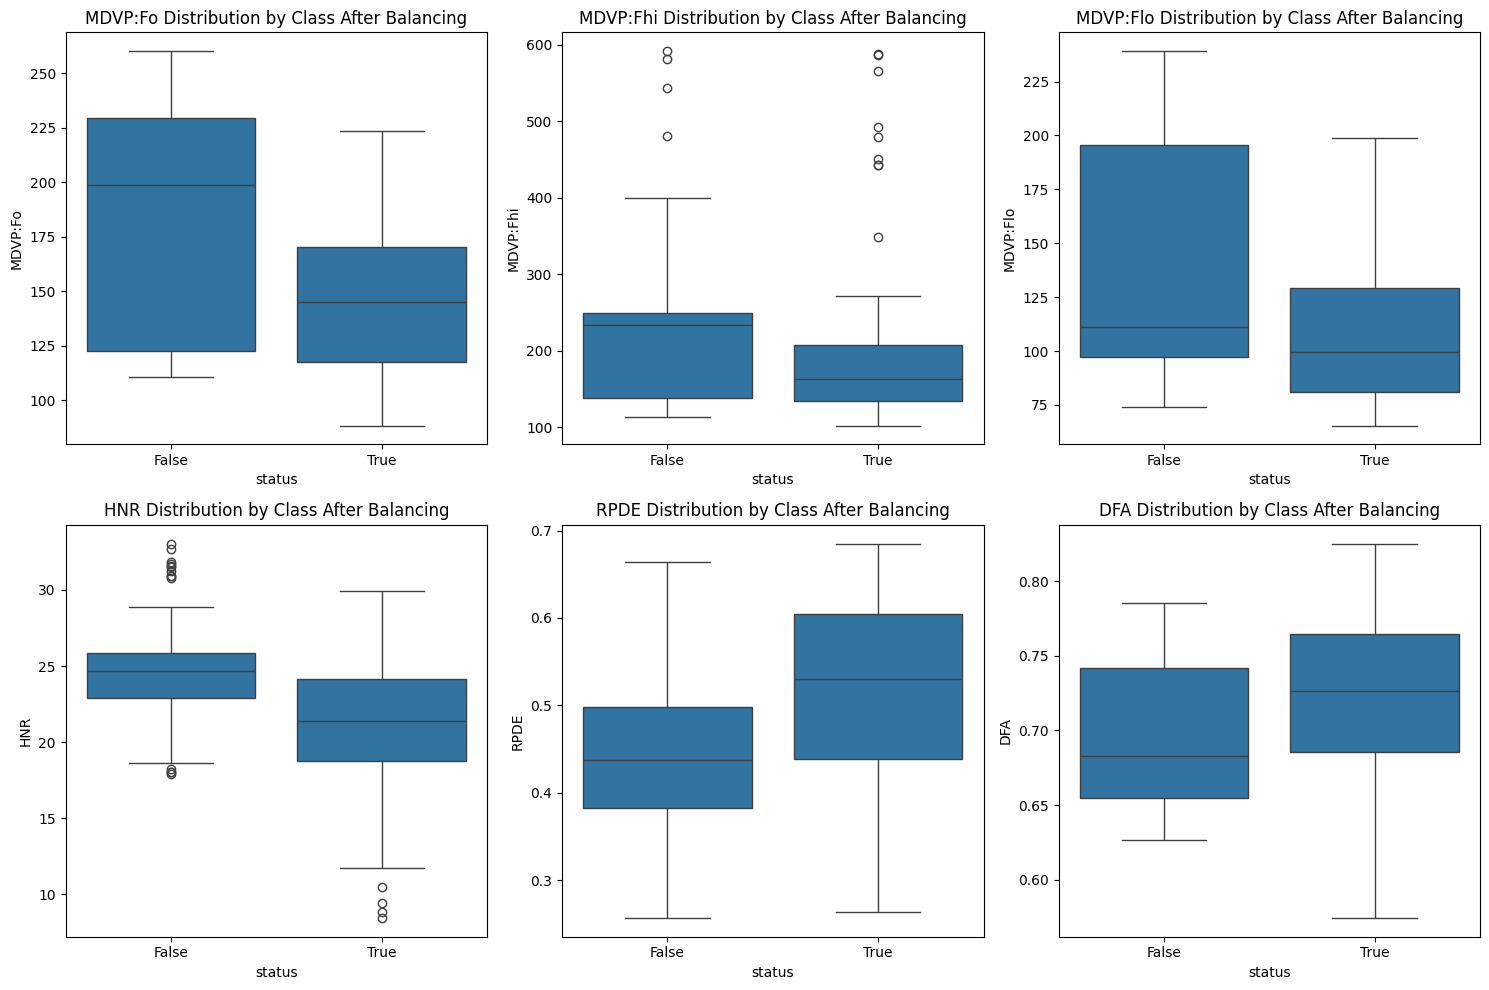

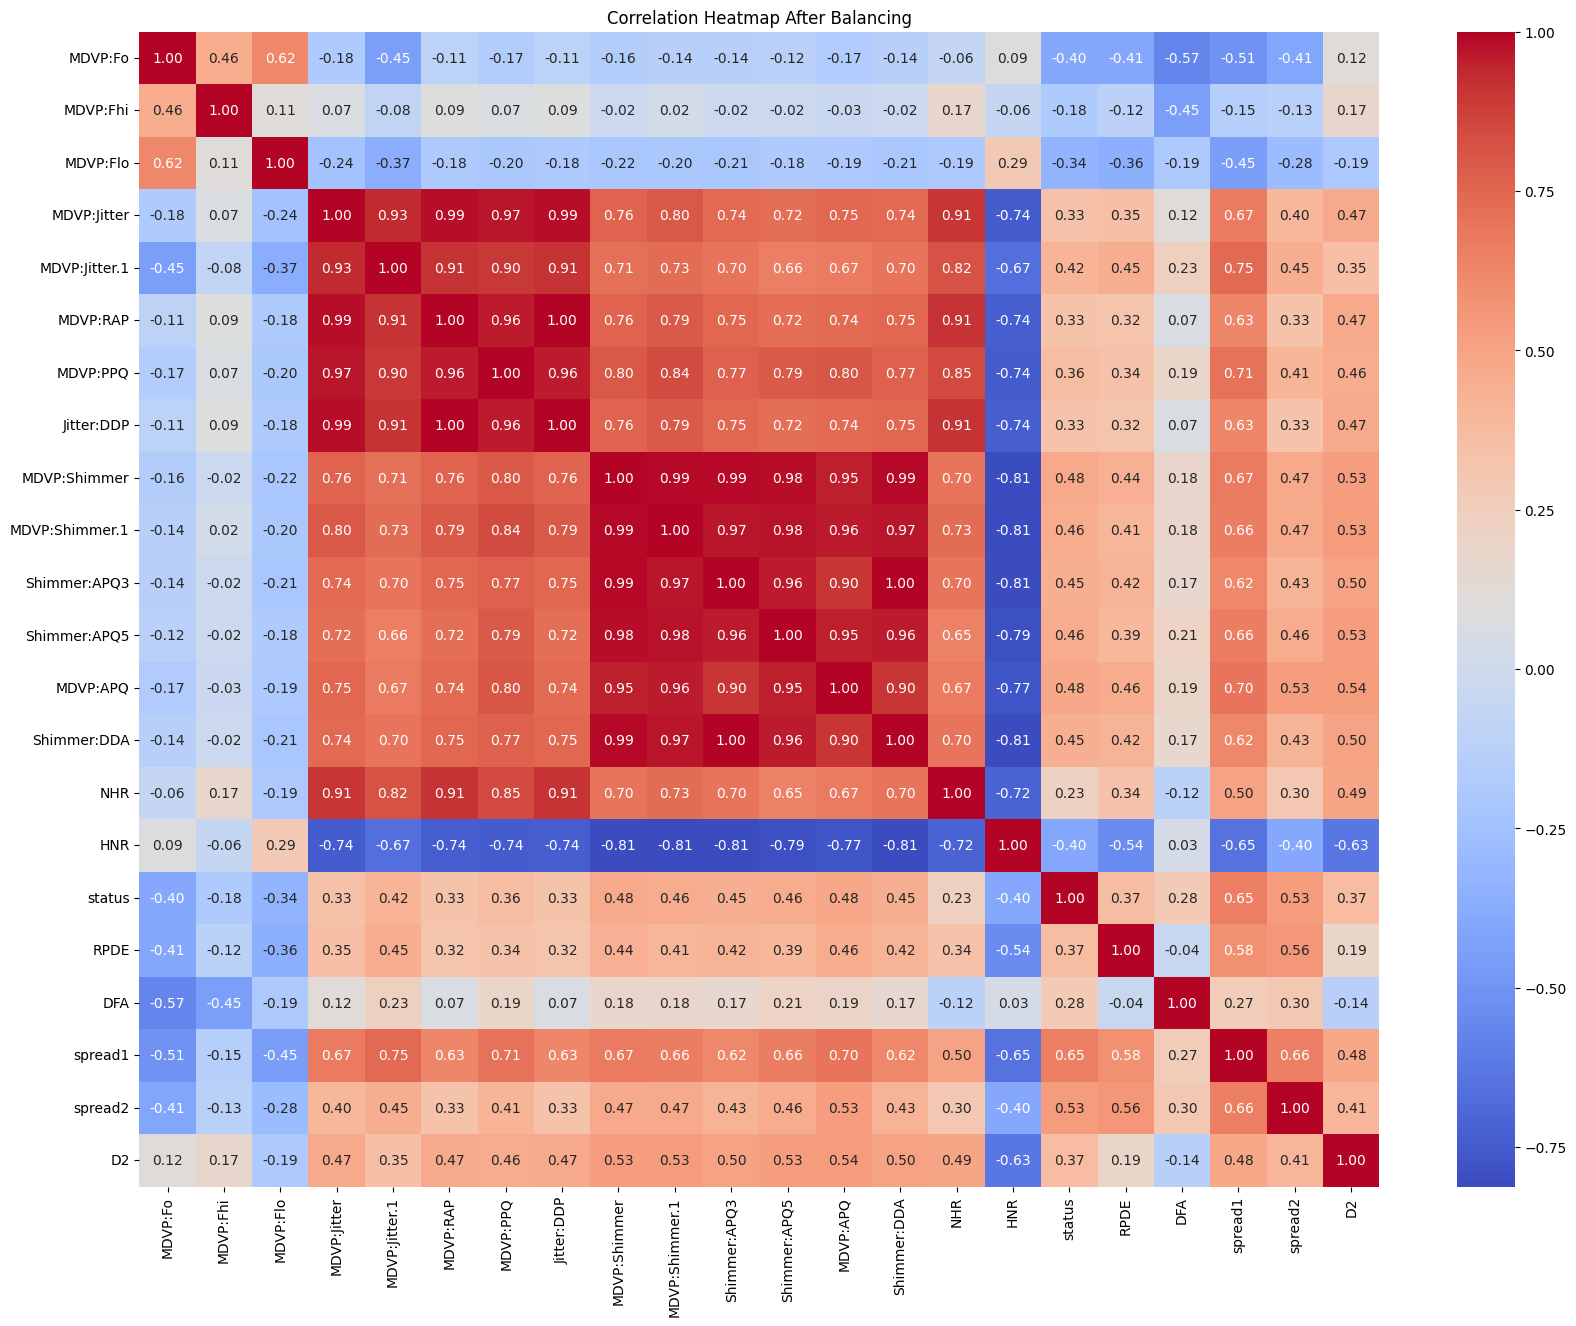

In [ ]:
# Convert balanced data arrays to DataFrame for easier plotting
df_balanced = pd.DataFrame(X, columns=df.columns[:-1])  # all columns except 'status'
df_balanced['status'] = y

# 1. Class distribution after balancing
plt.figure(figsize=(6,4))
sns.countplot(x='status', data=df_balanced)
plt.title('Class Distribution After Balancing')
plt.show()

# 2. Feature distributions after balancing for some selected features
features_to_plot = ['MDVP:Fo', 'MDVP:Fhi', 'MDVP:Flo', 'HNR', 'RPDE', 'DFA']  # Use exact names as in df.columns

plt.figure(figsize=(15,10))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='status', y=feature, data=df_balanced)
    plt.title(f'{feature} Distribution by Class After Balancing')
plt.tight_layout()
plt.show()

# 3. Correlation heatmap after balancing
plt.figure(figsize=(20,15))
sns.heatmap(df_balanced.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap After Balancing')
plt.show()


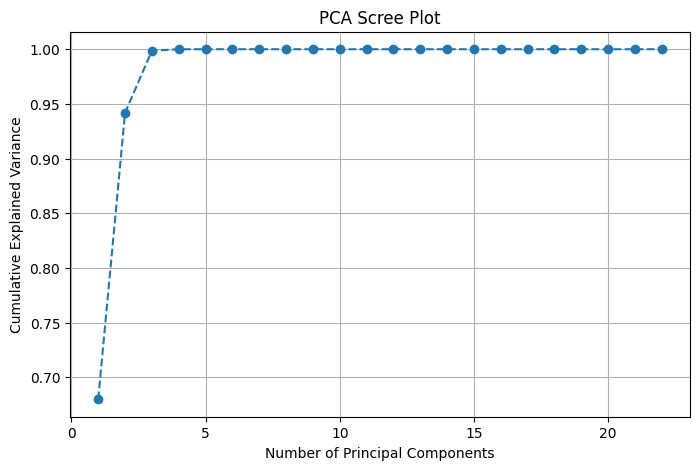

Number of PCA components explaining 95% variance: 3


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Apply PCA on the balanced feature data
pca = PCA()
pca.fit(X)

# Explained variance ratio
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Scree plot of explained variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree Plot')
plt.grid()
plt.show()

# Choose number of components that explain ~95% of variance
n_components = np.argmax(explained_variance >= 0.95) + 1
print(f"Number of PCA components explaining 95% variance: {n_components}")

# Transform data with selected components
pca = PCA(n_components=n_components)
x_pca = pca.fit_transform(X)


# Train test of PCA

In [ ]:
# Train-test split on PCA-transformed features
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(x_pca, Y_labels, test_size=0.20, random_state=20)

print("PCA Train features shape:", X_train_pca.shape)
print("PCA Test features shape:", X_test_pca.shape)


PCA Train features shape: (235, 3)
PCA Test features shape: (59, 3)


# MODEL TRAINING
In this section, we have trained the following Machine Learning Models:

*   Decision Tree Classifier
*   Random Forest Classifier
*   Logistic Regression
*   SVM
*   Naive Bayes
*   KNN Classifier
*   XGBoost Classifier

# **Decision Tree Classifier**

In [ ]:
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)
predDT = clf.predict(X_test)

print(classification_report(y_test, predDT))


              precision    recall  f1-score   support

       False       0.97      0.88      0.92        33
        True       0.86      0.96      0.91        26

    accuracy                           0.92        59
   macro avg       0.91      0.92      0.91        59
weighted avg       0.92      0.92      0.92        59



In [ ]:
param_grid = {
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth' :range(1,10),
    'random_state':range(30,210,30),
    'criterion' :['gini', 'entropy']
}
CV_dt = GridSearchCV(estimator=clf, param_grid=param_grid, cv= 5)
CV_dt.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
540 fits failed out of a total of 1620.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
540 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/uti

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(1, 10),
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'random_state': range(30, 210, 30)})

In [ ]:
CV_dt.best_params_

{'criterion': 'entropy',
 'max_depth': 6,
 'max_features': 'sqrt',
 'random_state': 120}

In [ ]:
dt1=DecisionTreeClassifier(random_state=120, max_features='sqrt', max_depth=6, criterion='entropy')
dt1.fit(X_train, y_train)
predDT = dt1.predict(X_test)
print(classification_report(y_test, predDT))

              precision    recall  f1-score   support

       False       0.91      0.97      0.94        33
        True       0.96      0.88      0.92        26

    accuracy                           0.93        59
   macro avg       0.94      0.93      0.93        59
weighted avg       0.93      0.93      0.93        59



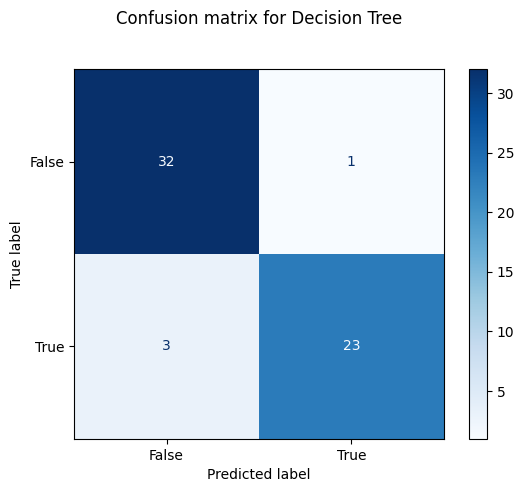

In [ ]:
disp = ConfusionMatrixDisplay.from_estimator(dt1, X_test, y_test, cmap=plt.cm.Blues)
plt.title('Confusion matrix for Decision Tree', y=1.1)
plt.show()

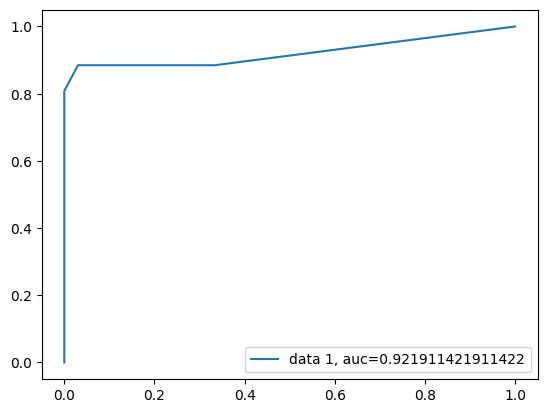

In [ ]:
y_pred_proba = dt1.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

In [ ]:
#joblib.dump(dt1, 'dt_clf.pkl')

# Random Forest Classifier

In [ ]:
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)
predRF = rfc.predict(X_test)

print(classification_report(y_test, predRF))

              precision    recall  f1-score   support

       False       0.89      0.97      0.93        33
        True       0.96      0.85      0.90        26

    accuracy                           0.92        59
   macro avg       0.92      0.91      0.91        59
weighted avg       0.92      0.92      0.91        59



In [ ]:
param_grid = {
    'n_estimators': range(50, 150, 25),
    'max_features': ['sqrt', 'log2'],
    'max_depth' :range(3, 8),
    'random_state':range(100,250,50),
    'criterion' :['gini', 'entropy']
}
CV_rfc = GridSearchCV(estimator=rfc, param_grid=param_grid, cv= 5)
CV_rfc.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(3, 8),
                         'max_features': ['sqrt', 'log2'],
                         'n_estimators': range(50, 150, 25),
                         'random_state': range(100, 250, 50)})

In [ ]:
CV_rfc.best_params_

{'criterion': 'entropy',
 'max_depth': 7,
 'max_features': 'sqrt',
 'n_estimators': 125,
 'random_state': 200}

In [ ]:
rfc1=RandomForestClassifier(random_state=200, max_features='sqrt', n_estimators= 125, max_depth=7, criterion='entropy')
rfc1.fit(X_train, y_train)
predRFC = rfc1.predict(X_test)
print(classification_report(y_test, predRFC))

              precision    recall  f1-score   support

       False       0.97      0.97      0.97        33
        True       0.96      0.96      0.96        26

    accuracy                           0.97        59
   macro avg       0.97      0.97      0.97        59
weighted avg       0.97      0.97      0.97        59



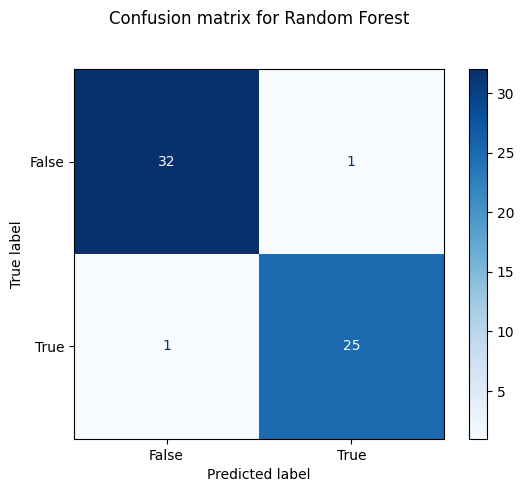

In [ ]:
disp = ConfusionMatrixDisplay.from_estimator(rfc1, X_test, y_test, cmap=plt.cm.Blues)
plt.title('Confusion matrix for Random Forest', y=1.1)
plt.show()

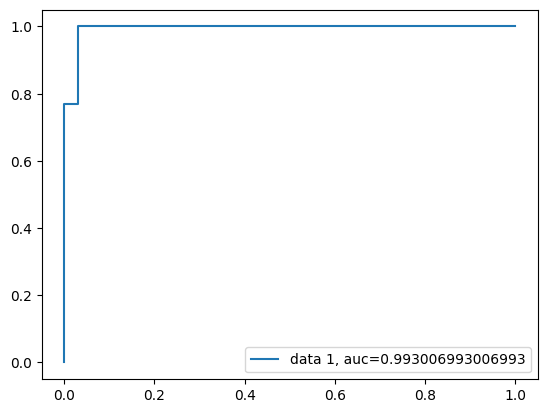

In [ ]:
y_pred_proba = rfc1.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

In [ ]:
# Dumping Random Forest Classifier
#joblib.dump(rfc1, 'rf_clf.pkl')

# random forest on pca

Fitting 5 folds for each of 80 candidates, totalling 400 fits
[CV 1/5] END criterion=gini, max_depth=3, max_features=sqrt, n_estimators=50, random_state=200;, score=0.717 total time=   0.1s
[CV 2/5] END criterion=gini, max_depth=3, max_features=sqrt, n_estimators=50, random_state=200;, score=0.750 total time=   0.1s
[CV 3/5] END criterion=gini, max_depth=3, max_features=sqrt, n_estimators=50, random_state=200;, score=0.776 total time=   0.1s
[CV 4/5] END criterion=gini, max_depth=3, max_features=sqrt, n_estimators=50, random_state=200;, score=0.800 total time=   0.1s
[CV 5/5] END criterion=gini, max_depth=3, max_features=sqrt, n_estimators=50, random_state=200;, score=0.772 total time=   0.1s
[CV 1/5] END criterion=gini, max_depth=3, max_features=sqrt, n_estimators=75, random_state=200;, score=0.692 total time=   0.1s
[CV 2/5] END criterion=gini, max_depth=3, max_features=sqrt, n_estimators=75, random_state=200;, score=0.778 total time=   0.1s
[CV 3/5] END criterion=gini, max_depth=3, 

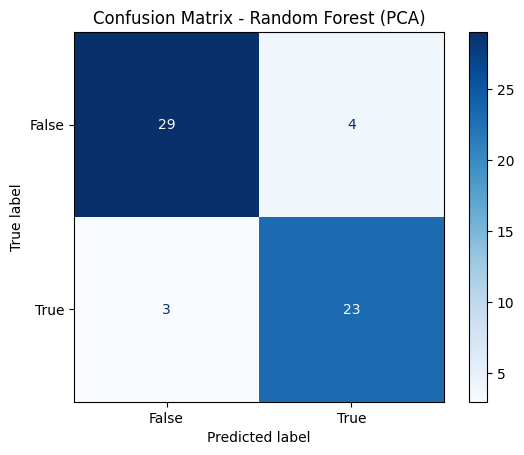

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Define parameter grid
param_grid_rf_pca = {
    'n_estimators': range(50, 150, 25),
    'max_features': ['sqrt', 'log2'],
    'max_depth': range(3, 8),
    'criterion': ['gini', 'entropy'],
    'random_state': [200]
}

# GridSearchCV on PCA train data
grid_rf_pca = GridSearchCV(estimator=RandomForestClassifier(), param_grid=param_grid_rf_pca, cv=5, scoring='f1', verbose=3)
grid_rf_pca.fit(X_train_pca, y_train_pca)

print("Best Parameters Random Forest PCA:", grid_rf_pca.best_params_)

# Train new model with best params
best_rf_pca = RandomForestClassifier(**grid_rf_pca.best_params_)
best_rf_pca.fit(X_train_pca, y_train_pca)

predRFC_pca = best_rf_pca.predict(X_test_pca)
print("Random Forest on PCA Transformed Features after GridSearchCV:")
print(classification_report(y_test_pca, predRFC_pca))

# Confusion matrix plot
disp_rf_pca = ConfusionMatrixDisplay.from_estimator(best_rf_pca, X_test_pca, y_test_pca, cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Random Forest (PCA)')
plt.show()


# Logistic Regression

In [ ]:
logmodel = LogisticRegression()
logmodel.fit(X_train, y_train)
predlog = logmodel.predict(X_test)

In [ ]:
print(classification_report(y_test, predlog))
print("Confusion Matrix:")
confusion_matrix(y_test, predlog)

              precision    recall  f1-score   support

       False       0.79      0.94      0.86        33
        True       0.90      0.69      0.78        26

    accuracy                           0.83        59
   macro avg       0.85      0.82      0.82        59
weighted avg       0.84      0.83      0.83        59

Confusion Matrix:


array([[31,  2],
       [ 8, 18]])

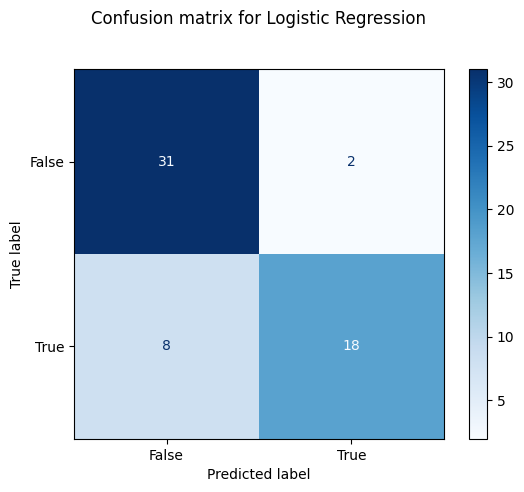

In [ ]:
disp = ConfusionMatrixDisplay.from_estimator(logmodel, X_test, y_test, cmap=plt.cm.Blues)
plt.title('Confusion matrix for Logistic Regression', y=1.1)
plt.show()

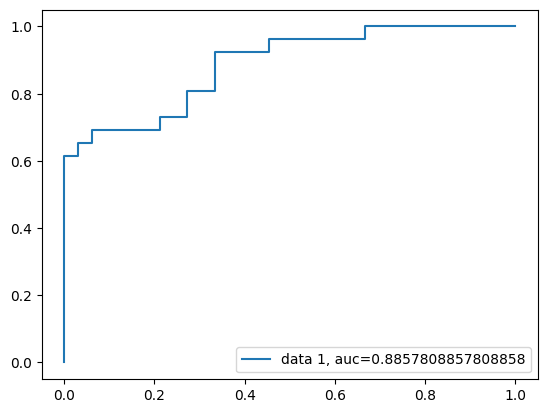

In [ ]:
y_pred_proba = logmodel.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()


In [ ]:
# Dumping Logistic Regression Model
#joblib.dump(logmodel, 'lg_clf.pkl')

# Logistic Regression on PCA


1. Logistic Regression on PCA Features
--------------------------------------------------

Logistic Regression on PCA Transformed Features:
              precision    recall  f1-score   support

       False       0.88      0.67      0.76        33
        True       0.68      0.88      0.77        26

    accuracy                           0.76        59
   macro avg       0.78      0.78      0.76        59
weighted avg       0.79      0.76      0.76        59



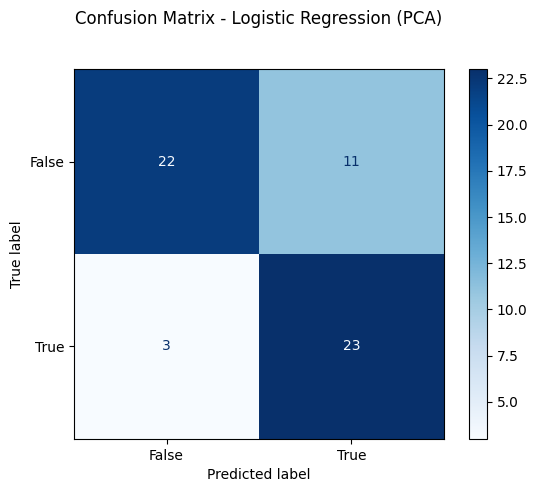

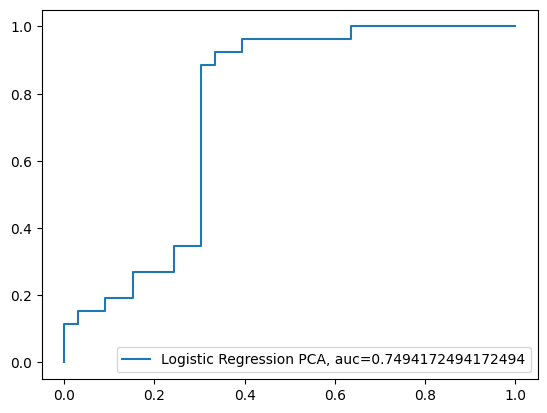

In [ ]:
# -------------------------------------------
# 1. LOGISTIC REGRESSION WITH PCA
# -------------------------------------------
print("\n1. Logistic Regression on PCA Features")
print("-" * 50)

logmodel_pca = LogisticRegression(max_iter=1000, random_state=42)
logmodel_pca.fit(X_train_pca, y_train_pca)
predlog_pca = logmodel_pca.predict(X_test_pca)

print("\nLogistic Regression on PCA Transformed Features:")
print(classification_report(y_test_pca, predlog_pca))

# Confusion Matrix
disp_lr_pca = ConfusionMatrixDisplay.from_estimator(
    logmodel_pca, X_test_pca, y_test_pca, cmap=plt.cm.Blues
)
plt.title('Confusion Matrix - Logistic Regression (PCA)', y=1.1)
plt.show()

# ROC Curve
y_pred_proba_lr_pca = logmodel_pca.predict_proba(X_test_pca)[::,1]
fpr_lr_pca, tpr_lr_pca, _ = metrics.roc_curve(y_test_pca, y_pred_proba_lr_pca)
auc_lr_pca = metrics.roc_auc_score(y_test_pca, y_pred_proba_lr_pca)

plt.plot(fpr_lr_pca, tpr_lr_pca, label="Logistic Regression PCA, auc="+str(auc_lr_pca))
plt.legend(loc=4)
plt.show()


# SVM

In [ ]:
#Create a svm Classifier
clf = svm.SVC(kernel='linear') # Linear Kernel

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Test Set Accuracy:",metrics.accuracy_score(y_test, y_pred))

X_pred = clf.predict(X_train)
print("Train Set Accuracy:",metrics.accuracy_score(y_train, X_pred))

Test Set Accuracy: 0.8135593220338984
Train Set Accuracy: 0.8638297872340426


In [ ]:
param_grid = {'kernel':['linear','rbf','poly'],'C': [0.5, 1, 10, 100],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001]}

grid_SVC = GridSearchCV(svm.SVC(), param_grid, scoring='f1', verbose = 3)
grid_SVC.fit(X_train, y_train)

# print best parameter after tuning
print("\nBest Parameters: ", grid_SVC.best_params_)

# print how our model looks after hyper-parameter tuning
print("\n", grid_SVC.best_estimator_)

predSVC = grid_SVC.predict(X_test)

# print classification report
print("\n", classification_report(y_test, predSVC))

Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV 1/5] END .....C=0.5, gamma=1, kernel=linear;, score=0.913 total time=   0.0s
[CV 2/5] END .....C=0.5, gamma=1, kernel=linear;, score=0.884 total time=   0.0s
[CV 3/5] END .....C=0.5, gamma=1, kernel=linear;, score=0.800 total time=   0.0s
[CV 4/5] END .....C=0.5, gamma=1, kernel=linear;, score=0.744 total time=   0.0s
[CV 5/5] END .....C=0.5, gamma=1, kernel=linear;, score=0.818 total time=   0.0s
[CV 1/5] END ........C=0.5, gamma=1, kernel=rbf;, score=0.939 total time=   0.0s
[CV 2/5] END ........C=0.5, gamma=1, kernel=rbf;, score=0.933 total time=   0.0s
[CV 3/5] END ........C=0.5, gamma=1, kernel=rbf;, score=0.889 total time=   0.0s
[CV 4/5] END ........C=0.5, gamma=1, kernel=rbf;, score=0.979 total time=   0.0s
[CV 5/5] END ........C=0.5, gamma=1, kernel=rbf;, score=0.894 total time=   0.0s
[CV 1/5] END .......C=0.5, gamma=1, kernel=poly;, score=0.894 total time=   0.0s
[CV 2/5] END .......C=0.5, gamma=1, kernel=poly

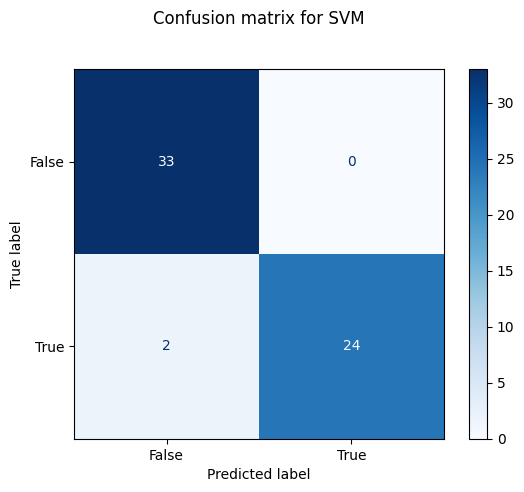

In [ ]:
disp = ConfusionMatrixDisplay.from_estimator(grid_SVC, X_test, y_test, cmap=plt.cm.Blues)
plt.title('Confusion matrix for SVM', y=1.1)
plt.show()

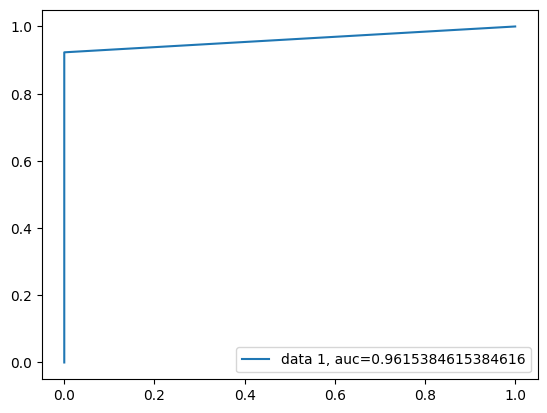

In [ ]:
fpr, tpr, _ = metrics.roc_curve(y_test,  predSVC)
auc = metrics.roc_auc_score(y_test, predSVC)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

In [ ]:
# Dumping SVM Classifier
#joblib.dump(grid_SVC, 'svm_clf.pkl')

# SVM WITH PCA


2. SVM on PCA Features with known best hyperparameters
--------------------------------------------------

SVM on PCA Transformed Features with Known Params:
              precision    recall  f1-score   support

       False       1.00      0.85      0.92        33
        True       0.84      1.00      0.91        26

    accuracy                           0.92        59
   macro avg       0.92      0.92      0.92        59
weighted avg       0.93      0.92      0.92        59



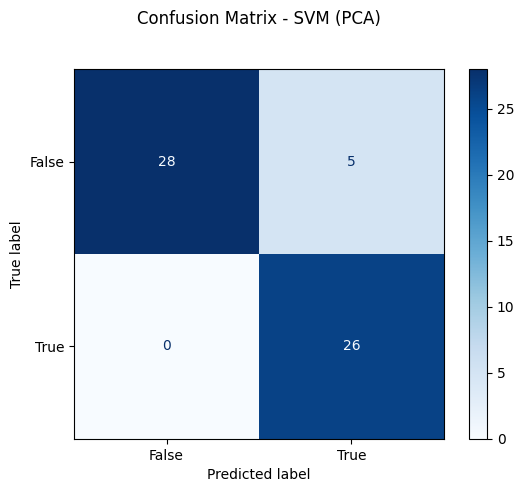

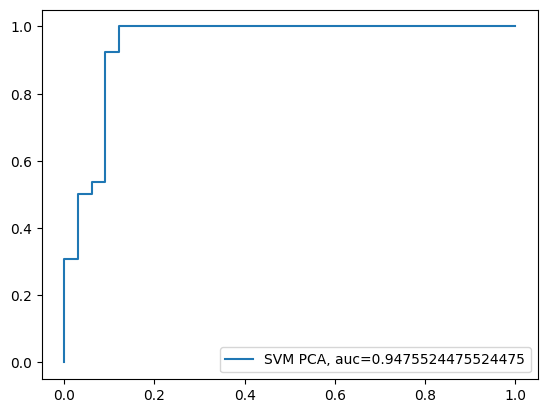

In [ ]:
from sklearn import svm
from sklearn.svm import SVC

#Best Parameters:  {'C': 100, 'gamma': 1, 'kernel': 'rbf'}
print("\n2. SVM on PCA Features with known best hyperparameters")
print("-" * 50)

# Instantiate SVM with best params found previously
svm_pca = svm.SVC(
    kernel='rbf',
    C=10,
    gamma=0.01,
    probability=True,
    random_state=42
)

# Fit on PCA-transformed training data
svm_pca.fit(X_train_pca, y_train_pca)

# Predict on PCA-transformed test data
predSVC_pca = svm_pca.predict(X_test_pca)

# Print classification report
print("\nSVM on PCA Transformed Features with Known Params:")
print(classification_report(y_test_pca, predSVC_pca))

# Confusion Matrix
disp_svm_pca = ConfusionMatrixDisplay.from_estimator(
    svm_pca, X_test_pca, y_test_pca, cmap=plt.cm.Blues
)
plt.title('Confusion Matrix - SVM (PCA)', y=1.1)
plt.show()

# ROC Curve
y_pred_proba_svm_pca = svm_pca.predict_proba(X_test_pca)[:, 1]
fpr_svm_pca, tpr_svm_pca, _ = metrics.roc_curve(y_test_pca, y_pred_proba_svm_pca)
auc_svm_pca = metrics.roc_auc_score(y_test_pca, y_pred_proba_svm_pca)

plt.plot(fpr_svm_pca, tpr_svm_pca, label="SVM PCA, auc="+str(auc_svm_pca))
plt.legend(loc=4)
plt.show()


# Naive bayes

In [ ]:
# Naive Bayes

gnb = Naive_Bayes()
gnb.fit(X_train, y_train)
predgnb = gnb.predict(X_test)

print(classification_report(y_test, predgnb))

              precision    recall  f1-score   support

       False       0.71      0.97      0.82        33
        True       0.93      0.50      0.65        26

    accuracy                           0.76        59
   macro avg       0.82      0.73      0.74        59
weighted avg       0.81      0.76      0.75        59



In [ ]:
print("Confusion Matrix:")
confusion_matrix(y_test, predgnb)

Confusion Matrix:


array([[32,  1],
       [13, 13]])

In [ ]:
accuracy_testing = accuracy_score(y_test, predgnb)
print("Accuracy % :",accuracy_testing*100)

Accuracy % : 76.27118644067797


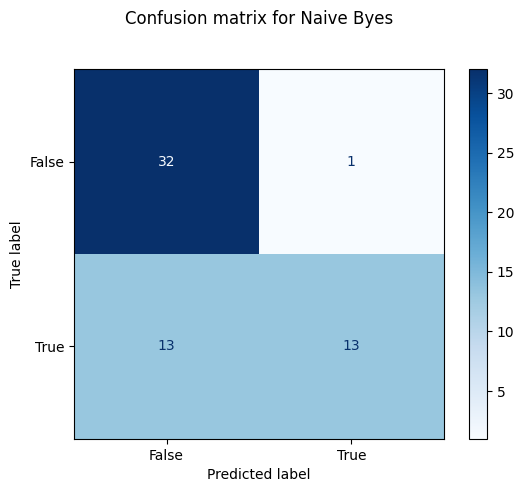

In [ ]:
disp = ConfusionMatrixDisplay.from_estimator(gnb, X_test, y_test, cmap=plt.cm.Blues)
plt.title('Confusion matrix for Naive Byes', y=1.1)
plt.show()

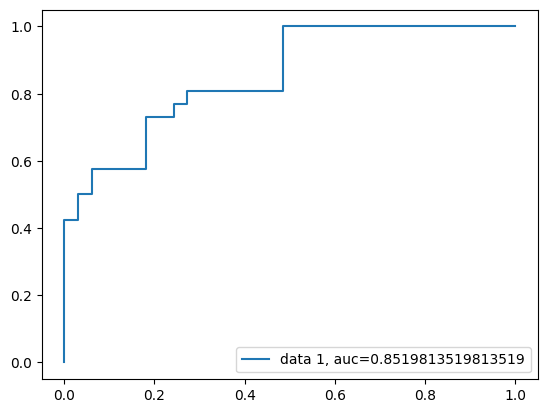

In [ ]:
y_pred_proba = gnb.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

In [ ]:
# Dumping Naive Bayes Classifier
#joblib.dump(gnb, 'nb_clf.pkl')

# Naive Bayes with PCA


3. Naive Bayes on PCA Features
--------------------------------------------------

Naive Bayes on PCA Transformed Features:
              precision    recall  f1-score   support

       False       0.85      0.67      0.75        33
        True       0.67      0.85      0.75        26

    accuracy                           0.75        59
   macro avg       0.76      0.76      0.75        59
weighted avg       0.77      0.75      0.75        59

Confusion Matrix:
Accuracy %: 74.57627118644068


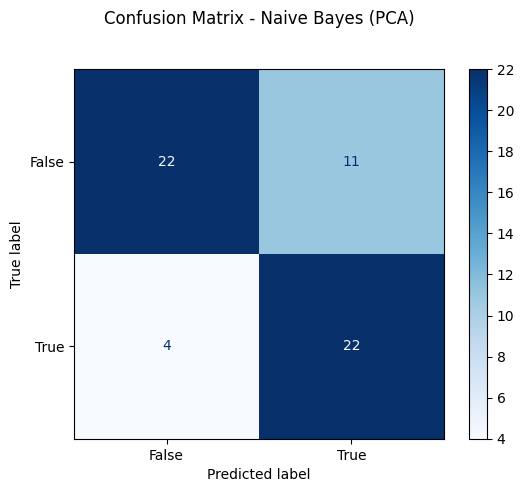

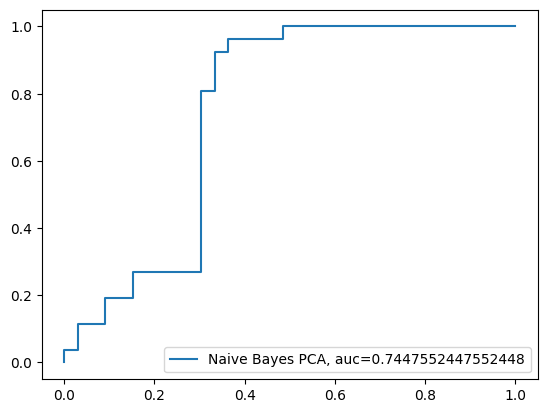

In [ ]:
# -------------------------------------------
# 3. NAIVE BAYES WITH PCA
# -------------------------------------------
print("\n3. Naive Bayes on PCA Features")
print("-" * 50)

# Naive Bayes on PCA
gnb_pca = Naive_Bayes()
gnb_pca.fit(X_train_pca, y_train_pca)
predgnb_pca = gnb_pca.predict(X_test_pca)

print("\nNaive Bayes on PCA Transformed Features:")
print(classification_report(y_test_pca, predgnb_pca))

print("Confusion Matrix:")
confusion_matrix(y_test_pca, predgnb_pca)

accuracy_testing_pca = accuracy_score(y_test_pca, predgnb_pca)
print("Accuracy %:", accuracy_testing_pca * 100)

# Confusion Matrix
disp_nb_pca = ConfusionMatrixDisplay.from_estimator(
    gnb_pca, X_test_pca, y_test_pca, cmap=plt.cm.Blues
)
plt.title('Confusion Matrix - Naive Bayes (PCA)', y=1.1)
plt.show()

# ROC Curve
y_pred_proba_nb_pca = gnb_pca.predict_proba(X_test_pca)[::,1]
fpr_nb_pca, tpr_nb_pca, _ = metrics.roc_curve(y_test_pca, y_pred_proba_nb_pca)
auc_nb_pca = metrics.roc_auc_score(y_test_pca, y_pred_proba_nb_pca)

plt.plot(fpr_nb_pca, tpr_nb_pca, label="Naive Bayes PCA, auc="+str(auc_nb_pca))
plt.legend(loc=4)
plt.show()


# KNN Classifier

In [ ]:
import numpy as np

Ks = 10
mean_acc = []
ConfustionMx = [];
for n in range(2,Ks):

    #Train Model and Predict
    neigh = KNeighborsClassifier(n_neighbors = n).fit(X_train,y_train)
    yhat=neigh.predict(X_test)
    mean_acc.append(metrics.accuracy_score(y_test, yhat))
print('Neighbor Accuracy List')
print(mean_acc)

Neighbor Accuracy List
[0.9491525423728814, 0.9661016949152542, 0.9661016949152542, 0.9661016949152542, 0.9152542372881356, 0.9152542372881356, 0.8983050847457628, 0.9152542372881356]


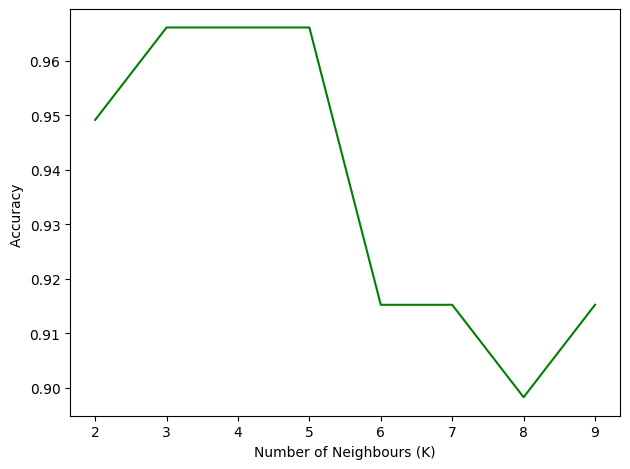

In [ ]:
plt.plot(range(2,Ks),mean_acc,'g')
plt.ylabel('Accuracy ')
plt.xlabel('Number of Neighbours (K)')
plt.tight_layout()
plt.show()

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
predKNN = knn.predict(X_test)

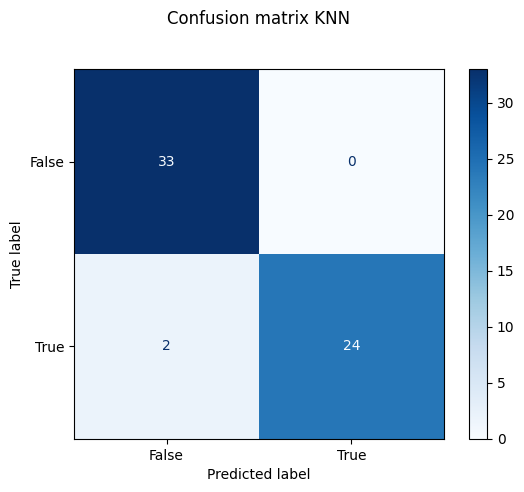

In [ ]:
disp = ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test, cmap=plt.cm.Blues)
plt.title('Confusion matrix KNN', y=1.1)
plt.show()

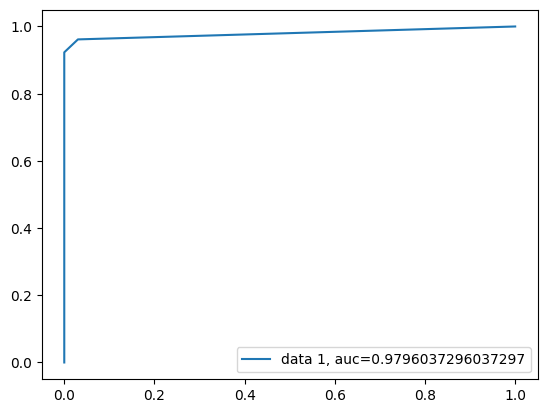

In [ ]:
y_pred_proba = knn.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()


In [ ]:
# Dumping KNN Classifier
#joblib.dump(knn, 'knn_clf.pkl')

# KNN with PCA


4. KNN on PCA Features
--------------------------------------------------
KNN Neighbor Accuracy List (PCA):
[0.864406779661017, 0.8813559322033898, 0.8813559322033898, 0.864406779661017, 0.847457627118644, 0.847457627118644, 0.847457627118644, 0.847457627118644]


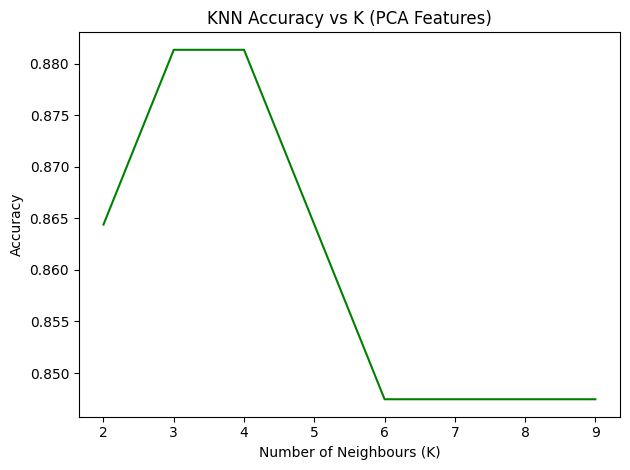


KNN (K=5) on PCA Transformed Features:
              precision    recall  f1-score   support

       False       0.88      0.88      0.88        33
        True       0.85      0.85      0.85        26

    accuracy                           0.86        59
   macro avg       0.86      0.86      0.86        59
weighted avg       0.86      0.86      0.86        59



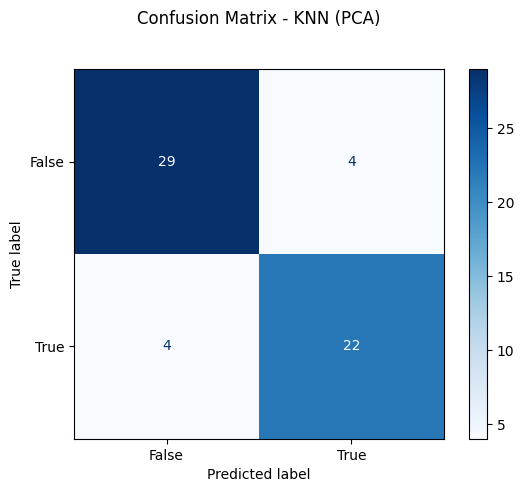

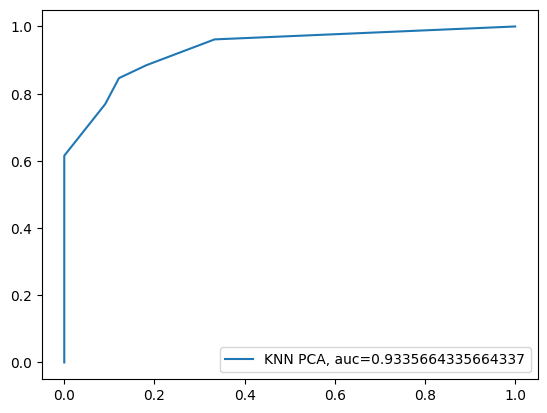

In [ ]:
# -------------------------------------------
# 4. KNN WITH PCA
# -------------------------------------------
print("\n4. KNN on PCA Features")
print("-" * 50)

import numpy as np

# Test different K values for KNN on PCA
Ks = 10
mean_acc_pca = []
ConfustionMx_pca = []

for n in range(2, Ks):
    # Train Model and Predict
    neigh_pca = KNeighborsClassifier(n_neighbors=n).fit(X_train_pca, y_train_pca)
    yhat_pca = neigh_pca.predict(X_test_pca)
    mean_acc_pca.append(metrics.accuracy_score(y_test_pca, yhat_pca))

print('KNN Neighbor Accuracy List (PCA):')
print(mean_acc_pca)

# Plot accuracy vs K
plt.plot(range(2, Ks), mean_acc_pca, 'g')
plt.ylabel('Accuracy')
plt.xlabel('Number of Neighbours (K)')
plt.title('KNN Accuracy vs K (PCA Features)')
plt.tight_layout()
plt.show()

# Train final KNN with optimal K (K=5)
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train_pca)
predKNN_pca = knn_pca.predict(X_test_pca)

print("\nKNN (K=5) on PCA Transformed Features:")
print(classification_report(y_test_pca, predKNN_pca))

# Confusion Matrix
disp_knn_pca = ConfusionMatrixDisplay.from_estimator(
    knn_pca, X_test_pca, y_test_pca, cmap=plt.cm.Blues
)
plt.title('Confusion Matrix - KNN (PCA)', y=1.1)
plt.show()

# ROC Curve
y_pred_proba_knn_pca = knn_pca.predict_proba(X_test_pca)[::,1]
fpr_knn_pca, tpr_knn_pca, _ = metrics.roc_curve(y_test_pca, y_pred_proba_knn_pca)
auc_knn_pca = metrics.roc_auc_score(y_test_pca, y_pred_proba_knn_pca)

plt.plot(fpr_knn_pca, tpr_knn_pca, label="KNN PCA, auc="+str(auc_knn_pca))
plt.legend(loc=4)
plt.show()


# XGBoost Classifer

In this section, we have trained a XGBoost Classifier, for classification of Instances to be Parkinsons or Not. The following parameters of the XGBoost Classifier have been optimized in this section:

Max Depth: This value is used to determine the Maximum Depth of the Tree.
ETA : This is also known as Learning Rate.
Reg_Lambda : This is the L2 Regularization for the weights.
Random State : This is used to evaluate and determine the performance of the model based on different random states.
The Parameter Optimization has been performed using GridSearchCV with the following parameters:

Scoring Parameter: F1 Score
Cross Validation: 3

In [ ]:
# Defining Parameter Dictionary
param_dict = {'max_depth': range(4,8), 'eta' : [0.1, 0.2, 0.3, 0.4, 0.5],
              'reg_lambda' : [0.8, 0.9, 1, 1.1, 1.2],
              'random_state': [300, 600, 900]}

In [ ]:
clf = GridSearchCV(XGBClassifier(), param_grid = param_dict,
                   scoring = 'f1', cv = 3, verbose = 1)
clf.fit(X_train, y_train)

Fitting 3 folds for each of 300 candidates, totalling 900 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'eta': [0.1, 0.2, 0.3, 0.4, 0.5],
                         'max_depth': range(4, 8),
                         'random_state': [300, 600, 900],
                         'reg_lambda': [0.8, 0.9, 1, 1.1, 1.2]},
             scoring='f1', verbose=1)

In [ ]:
print('Best Score :', clf.best_score_)
print('Best Parameters :', clf.best_params_)

Best Score : 0.954492328287509
Best Parameters : {'eta': 0.4, 'max_depth': 4, 'random_state': 300, 'reg_lambda': 1.2}


In [ ]:
# Extracting Best Classifier From GridSearchCV
xgb_clf = clf.best_estimator_

In [ ]:
# Evaluating Performance on Train Set
pred = xgb_clf.predict(X_train)
print('For Train Set')
print('Accuracy :', metrics.accuracy_score(y_train, pred))
print('Precision :', metrics.precision_score(y_train, pred))
print('Recall :', metrics.recall_score(y_train, pred))
print('R2 Score :', metrics.r2_score(y_train, pred))

For Train Set
Accuracy : 1.0
Precision : 1.0
Recall : 1.0
R2 Score : 1.0


In [ ]:
# Evaluating Performance on Train Set
# Evaluating Performance on Train Set
predXGB = xgb_clf.predict(X_test)
print('For Test Set')
print('Accuracy :', metrics.accuracy_score(y_test, predXGB))
print('Precision :', metrics.precision_score(y_test, predXGB))
print('Recall :', metrics.recall_score(y_test, predXGB))
print('R2 Score :', metrics.r2_score(y_test, predXGB))

For Test Set
Accuracy : 0.9322033898305084
Precision : 0.8928571428571429
Recall : 0.9615384615384616
R2 Score : 0.7249417249417249


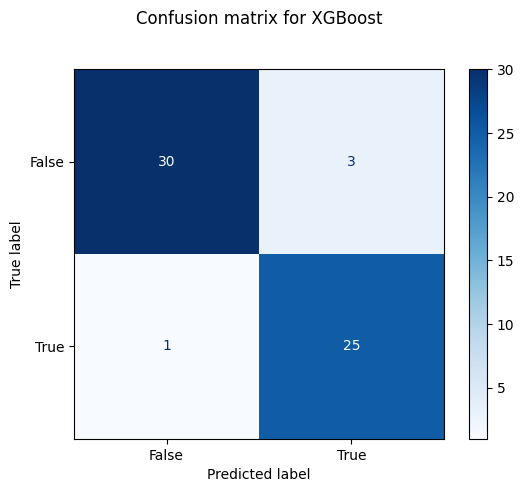

In [ ]:
ConfusionMatrixDisplay.from_estimator(xgb_clf, X_test, y_test, cmap=plt.cm.Blues)
plt.title('Confusion matrix for XGBoost', y=1.1)
plt.show()

In [ ]:
# Dumping XGBoost Classifier
#joblib.dump(xgb_clf, 'xgb_clf.pkl')

# XGBoost on PCA

Fitting 3 folds for each of 100 candidates, totalling 300 fits
[CV 1/3] END eta=0.1, max_depth=4, random_state=42, reg_lambda=0.8;, score=0.744 total time=   0.0s
[CV 2/3] END eta=0.1, max_depth=4, random_state=42, reg_lambda=0.8;, score=0.779 total time=   0.0s
[CV 3/3] END eta=0.1, max_depth=4, random_state=42, reg_lambda=0.8;, score=0.810 total time=   0.0s
[CV 1/3] END eta=0.1, max_depth=4, random_state=42, reg_lambda=0.9;, score=0.734 total time=   0.0s
[CV 2/3] END eta=0.1, max_depth=4, random_state=42, reg_lambda=0.9;, score=0.785 total time=   0.0s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:28:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:28:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:28:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:28:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

[CV 3/3] END eta=0.1, max_depth=4, random_state=42, reg_lambda=0.9;, score=0.810 total time=   0.0s
[CV 1/3] END eta=0.1, max_depth=4, random_state=42, reg_lambda=1;, score=0.734 total time=   0.0s
[CV 2/3] END eta=0.1, max_depth=4, random_state=42, reg_lambda=1;, score=0.789 total time=   0.0s
[CV 3/3] END eta=0.1, max_depth=4, random_state=42, reg_lambda=1;, score=0.786 total time=   0.0s
[CV 1/3] END eta=0.1, max_depth=4, random_state=42, reg_lambda=1.1;, score=0.734 total time=   0.0s
[CV 2/3] END eta=0.1, max_depth=4, random_state=42, reg_lambda=1.1;, score=0.769 total time=   0.0s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:28:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:28:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:28:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:28:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

[CV 3/3] END eta=0.1, max_depth=4, random_state=42, reg_lambda=1.1;, score=0.814 total time=   0.0s
[CV 1/3] END eta=0.1, max_depth=4, random_state=42, reg_lambda=1.2;, score=0.734 total time=   0.0s
[CV 2/3] END eta=0.1, max_depth=4, random_state=42, reg_lambda=1.2;, score=0.779 total time=   0.0s
[CV 3/3] END eta=0.1, max_depth=4, random_state=42, reg_lambda=1.2;, score=0.800 total time=   0.0s
[CV 1/3] END eta=0.1, max_depth=5, random_state=42, reg_lambda=0.8;, score=0.744 total time=   0.0s
[CV 2/3] END eta=0.1, max_depth=5, random_state=42, reg_lambda=0.8;, score=0.779 total time=   0.0s


...

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:28:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:28:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:28:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:28:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

[CV 2/3] END eta=0.5, max_depth=7, random_state=42, reg_lambda=0.9;, score=0.789 total time=   0.0s
[CV 3/3] END eta=0.5, max_depth=7, random_state=42, reg_lambda=0.9;, score=0.791 total time=   0.0s
[CV 1/3] END eta=0.5, max_depth=7, random_state=42, reg_lambda=1;, score=0.800 total time=   0.0s
[CV 2/3] END eta=0.5, max_depth=7, random_state=42, reg_lambda=1;, score=0.800 total time=   0.0s
[CV 3/3] END eta=0.5, max_depth=7, random_state=42, reg_lambda=1;, score=0.771 total time=   0.0s
[CV 1/3] END eta=0.5, max_depth=7, random_state=42, reg_lambda=1.1;, score=0.785 total time=   0.0s
[CV 2/3] END eta=0.5, max_depth=7, random_state=42, reg_lambda=1.1;, score=0.850 total time=   0.0s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:28:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:28:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:28:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:28:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

[CV 3/3] END eta=0.5, max_depth=7, random_state=42, reg_lambda=1.1;, score=0.786 total time=   0.0s
[CV 1/3] END eta=0.5, max_depth=7, random_state=42, reg_lambda=1.2;, score=0.800 total time=   0.0s
[CV 2/3] END eta=0.5, max_depth=7, random_state=42, reg_lambda=1.2;, score=0.810 total time=   0.0s
[CV 3/3] END eta=0.5, max_depth=7, random_state=42, reg_lambda=1.2;, score=0.800 total time=   0.0s
Best Parameters XGBoost PCA: {'eta': 0.4, 'max_depth': 7, 'random_state': 42, 'reg_lambda': 1.2}
XGBoost on PCA Transformed Features after GridSearchCV:
              precision    recall  f1-score   support

       False       0.87      0.82      0.84        33
        True       0.79      0.85      0.81        26

    accuracy                           0.83        59
   macro avg       0.83      0.83      0.83        59
weighted avg       0.83      0.83      0.83        59



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:28:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:28:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:28:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:28:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


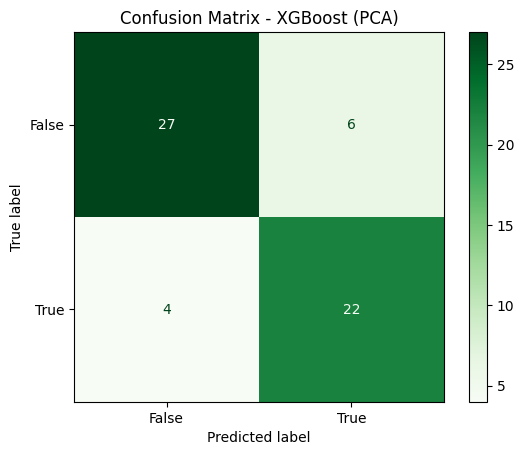

In [ ]:
# Parameter grid matching your mp.py
param_grid_xgb_pca = {
    'max_depth': range(4, 8),
    'eta': [0.1, 0.2, 0.3, 0.4, 0.5],
    'reg_lambda': [0.8, 0.9, 1, 1.1, 1.2],
    'random_state': [42]
}

grid_xgb_pca = GridSearchCV(estimator=XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
                            param_grid=param_grid_xgb_pca, cv=3, scoring='f1', verbose=3)
grid_xgb_pca.fit(X_train_pca, y_train_pca)

print("Best Parameters XGBoost PCA:", grid_xgb_pca.best_params_)

best_xgb_pca = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', **grid_xgb_pca.best_params_)
best_xgb_pca.fit(X_train_pca, y_train_pca)

predXGB_pca = best_xgb_pca.predict(X_test_pca)
print("XGBoost on PCA Transformed Features after GridSearchCV:")
print(classification_report(y_test_pca, predXGB_pca))

disp_xgb_pca = ConfusionMatrixDisplay.from_estimator(best_xgb_pca, X_test_pca, y_test_pca, cmap=plt.cm.Greens)
plt.title('Confusion Matrix - XGBoost (PCA)')
plt.show()


# Comparision Table

In [ ]:
from sklearn.metrics import precision_score,recall_score ,accuracy_score, f1_score, r2_score, log_loss

chart = {
        'Metric':["Accuracy", "F1-Score", "Recall", "Precision", "R2-Score"],
        'DT':[accuracy_score(y_test, predDT), f1_score(y_test, predDT), recall_score(y_test, predDT), precision_score(y_test, predDT), r2_score(y_test, predDT)],
        'RF':[accuracy_score(y_test, predRFC), f1_score(y_test, predRFC), recall_score(y_test, predRFC), precision_score(y_test, predRFC), r2_score(y_test, predRFC)],
        'LR':[accuracy_score(y_test, predlog), f1_score(y_test, predlog), recall_score(y_test, predlog), precision_score(y_test, predlog), r2_score(y_test, predlog)],
        'SVM':[accuracy_score(y_test, predSVC), f1_score(y_test, predSVC), recall_score(y_test, predSVC), precision_score(y_test, predSVC), r2_score(y_test, predSVC)],
        'NB':[accuracy_score(y_test, predgnb), f1_score(y_test, predgnb), recall_score(y_test, predgnb), precision_score(y_test, predgnb), r2_score(y_test, predgnb)],
        'KNN':[accuracy_score(y_test, predKNN), f1_score(y_test, predKNN), recall_score(y_test, predKNN), precision_score(y_test, predKNN), r2_score(y_test, predKNN)],
        'XGB':[accuracy_score(y_test, predXGB), f1_score(y_test, predXGB), recall_score(y_test, predXGB), precision_score(y_test, predXGB), r2_score(y_test, predXGB)]
}
chart = pd.DataFrame(chart)

In [ ]:
display(chart)

,Metric,DT,RF,LR,SVM,NB,KNN,XGB
0,Accuracy,0.932203,0.966102,0.830508,0.966102,0.762712,0.966102,0.932203
1,F1-Score,0.920000,0.961538,0.782609,0.960000,0.650000,0.960000,0.925926
2,Recall,0.884615,0.961538,0.692308,0.923077,0.500000,0.923077,0.961538
3,Precision,0.958333,0.961538,0.900000,1.000000,0.928571,1.000000,0.892857
4,R2-Score,0.724942,0.862471,0.312354,0.862471,0.037296,0.862471,0.724942


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, r2_score

def calculate_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='weighted'),
        "Recall": recall_score(y_true, y_pred, average='weighted'),
        "F1_Score": f1_score(y_true, y_pred, average='weighted'),
        "R2_Score": r2_score(y_true, y_pred)
    }

# Calculate metrics for each model variant
metrics_rf = calculate_metrics(y_test, predRFC)
metrics_rf_pca = calculate_metrics(y_test_pca, predRFC_pca)  # PCA RF

metrics_xgb = calculate_metrics(y_test, predXGB)  # non-PCA XGBoost
metrics_xgb_pca = calculate_metrics(y_test_pca, predXGB_pca)  # PCA XGBoost

# Create comparison table
comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "Random Forest (PCA)", "XGBoost", "XGBoost (PCA)"],
    "Accuracy": [metrics_rf["Accuracy"], metrics_rf_pca["Accuracy"], metrics_xgb["Accuracy"], metrics_xgb_pca["Accuracy"]],
    "Precision": [metrics_rf["Precision"], metrics_rf_pca["Precision"], metrics_xgb["Precision"], metrics_xgb_pca["Precision"]],
    "Recall": [metrics_rf["Recall"], metrics_rf_pca["Recall"], metrics_xgb["Recall"], metrics_xgb_pca["Recall"]],
    "F1 Score": [metrics_rf["F1_Score"], metrics_rf_pca["F1_Score"], metrics_xgb["F1_Score"], metrics_xgb_pca["F1_Score"]],
    "R2 Score": [metrics_rf["R2_Score"], metrics_rf_pca["R2_Score"], metrics_xgb["R2_Score"], metrics_xgb_pca["R2_Score"]]
})

print(comparison_df)


                 Model  Accuracy  Precision    Recall  F1 Score  R2 Score
0        Random Forest  0.966102   0.966102  0.966102  0.966102  0.862471
1  Random Forest (PCA)  0.881356   0.882278  0.881356  0.881563  0.518648
2              XGBoost  0.932203   0.934742  0.932203  0.932400  0.724942
3        XGBoost (PCA)  0.830508   0.833398  0.830508  0.830999  0.312354


In [ ]:
# ============================================
# LEARNING SECTION: Correct SMOTE Implementation
# ============================================
print("="*70)
print("FIXING DATA LEAKAGE: Implementing Correct SMOTE Workflow")
print("="*70)
print("\nPrevious approach: SMOTE → Split → Train (Data Leakage)")
print("Correct approach: Split → SMOTE on Training Only → Train\n")

# Step 1: Split FIRST (using original data before SMOTE)
X_correct = df.drop(['status'], axis=1)
y_correct = df['status']

X_train_correct, X_test_correct, y_train_correct, y_test_correct = train_test_split(
    X_correct, y_correct, test_size=0.2, random_state=42, stratify=y_correct
)

print(f"After split (before SMOTE):")
print(f"Training set: {X_train_correct.shape[0]} samples")
print(f"  - Class 0 (Healthy): {(y_train_correct == 0).sum()}")
print(f"  - Class 1 (Parkinson's): {(y_train_correct == 1).sum()}")
print(f"Test set: {X_test_correct.shape[0]} samples")
print(f"  - Class 0 (Healthy): {(y_test_correct == 0).sum()}")
print(f"  - Class 1 (Parkinson's): {(y_test_correct == 1).sum()}\n")

# Step 2: Apply SMOTE ONLY on training data
smote_correct = SMOTE(random_state=300) #42
X_train_correct_smote, y_train_correct_smote = smote_correct.fit_resample(X_train_correct, y_train_correct)

print(f"After SMOTE on training set only:")
print(f"Training set: {X_train_correct_smote.shape[0]} samples")
print(f"  - Class 0 (Healthy): {(y_train_correct_smote == 0).sum()}")
print(f"  - Class 1 (Parkinson's): {(y_train_correct_smote == 1).sum()}")
print(f"Test set: {X_test_correct.shape[0]} samples (UNCHANGED - No SMOTE)")
print(f"  - Class 0 (Healthy): {(y_test_correct == 0).sum()}")
print(f"  - Class 1 (Parkinson's): {(y_test_correct == 1).sum()}\n")

# Step 3: Scale features (fit on training, transform both)
scaler_correct = MinMaxScaler(feature_range=(-1, 1))
X_train_correct_scaled = scaler_correct.fit_transform(X_train_correct_smote)
X_test_correct_scaled = scaler_correct.transform(X_test_correct)  # Only transform, don't fit

print("="*70)
print("Training Models with Correct SMOTE Implementation")
print("="*70)

# Dictionary to store results
correct_results = {}

# 1. Decision Tree
print("\n1. Training Decision Tree...")
dt_correct = DecisionTreeClassifier(max_depth=6,max_features='sqrt', criterion='entropy', random_state=120)
dt_correct.fit(X_train_correct_scaled, y_train_correct_smote)
y_pred_dt_correct = dt_correct.predict(X_test_correct_scaled)

correct_results['Decision Tree'] = {
    'Accuracy': accuracy_score(y_test_correct, y_pred_dt_correct),
    'Precision': metrics.precision_score(y_test_correct, y_pred_dt_correct),
    'Recall': metrics.recall_score(y_test_correct, y_pred_dt_correct),
    'F1-Score': metrics.f1_score(y_test_correct, y_pred_dt_correct),
    'ROC-AUC': metrics.roc_auc_score(y_test_correct, y_pred_dt_correct)
}

# 2. Random Forest
print("2. Training Random Forest...")
rf_correct = RandomForestClassifier(n_estimators=125, max_depth=7, criterion='entropy', max_features = 'sqrt',random_state=200)
rf_correct.fit(X_train_correct_scaled, y_train_correct_smote)
y_pred_rf_correct = rf_correct.predict(X_test_correct_scaled)

correct_results['Random Forest'] = {
    'Accuracy': accuracy_score(y_test_correct, y_pred_rf_correct),
    'Precision': metrics.precision_score(y_test_correct, y_pred_rf_correct),
    'Recall': metrics.recall_score(y_test_correct, y_pred_rf_correct),
    'F1-Score': metrics.f1_score(y_test_correct, y_pred_rf_correct),
    'ROC-AUC': metrics.roc_auc_score(y_test_correct, y_pred_rf_correct)
}

# 3. Logistic Regression
print("3. Training Logistic Regression...")
lr_correct = LogisticRegression(max_iter=1000, random_state=42)
lr_correct.fit(X_train_correct_scaled, y_train_correct_smote)
y_pred_lr_correct = lr_correct.predict(X_test_correct_scaled)

correct_results['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test_correct, y_pred_lr_correct),
    'Precision': metrics.precision_score(y_test_correct, y_pred_lr_correct),
    'Recall': metrics.recall_score(y_test_correct, y_pred_lr_correct),
    'F1-Score': metrics.f1_score(y_test_correct, y_pred_lr_correct),
    'ROC-AUC': metrics.roc_auc_score(y_test_correct, y_pred_lr_correct)
}

# 4. SVM
print("4. Training SVM...")
svm_correct = SVC(kernel='rbf', random_state=42, probability=True)
svm_correct.fit(X_train_correct_scaled, y_train_correct_smote)
y_pred_svm_correct = svm_correct.predict(X_test_correct_scaled)

correct_results['SVM'] = {
    'Accuracy': accuracy_score(y_test_correct, y_pred_svm_correct),
    'Precision': metrics.precision_score(y_test_correct, y_pred_svm_correct),
    'Recall': metrics.recall_score(y_test_correct, y_pred_svm_correct),
    'F1-Score': metrics.f1_score(y_test_correct, y_pred_svm_correct),
    'ROC-AUC': metrics.roc_auc_score(y_test_correct, y_pred_svm_correct)
}

# 5. Naive Bayes
print("5. Training Naive Bayes...")
nb_correct = Naive_Bayes()
nb_correct.fit(X_train_correct_scaled, y_train_correct_smote)
y_pred_nb_correct = nb_correct.predict(X_test_correct_scaled)

correct_results['Naive Bayes'] = {
    'Accuracy': accuracy_score(y_test_correct, y_pred_nb_correct),
    'Precision': metrics.precision_score(y_test_correct, y_pred_nb_correct),
    'Recall': metrics.recall_score(y_test_correct, y_pred_nb_correct),
    'F1-Score': metrics.f1_score(y_test_correct, y_pred_nb_correct),
    'ROC-AUC': metrics.roc_auc_score(y_test_correct, y_pred_nb_correct)
}

# 6. KNN
print("6. Training KNN...")
knn_correct = KNeighborsClassifier(n_neighbors=5)
knn_correct.fit(X_train_correct_scaled, y_train_correct_smote)
y_pred_knn_correct = knn_correct.predict(X_test_correct_scaled)

correct_results['KNN'] = {
    'Accuracy': accuracy_score(y_test_correct, y_pred_knn_correct),
    'Precision': metrics.precision_score(y_test_correct, y_pred_knn_correct),
    'Recall': metrics.recall_score(y_test_correct, y_pred_knn_correct),
    'F1-Score': metrics.f1_score(y_test_correct, y_pred_knn_correct),
    'ROC-AUC': metrics.roc_auc_score(y_test_correct, y_pred_knn_correct)
}


# 7. XGBoost
print("7. Training XGBoost...")
import xgboost as xgb
xgb_correct = xgb.XGBClassifier(max_depth=4, eta=0.4, reg_lambda=1.2, random_state=300)
xgb_correct.fit(X_train_correct_scaled, y_train_correct_smote)
y_pred_xgb_correct = xgb_correct.predict(X_test_correct_scaled)

correct_results['XGBoost'] = {
    'Accuracy': accuracy_score(y_test_correct, y_pred_xgb_correct),
    'Precision': metrics.precision_score(y_test_correct, y_pred_xgb_correct),
    'Recall': metrics.recall_score(y_test_correct, y_pred_xgb_correct),
    'F1-Score': metrics.f1_score(y_test_correct, y_pred_xgb_correct),
    'ROC-AUC': metrics.roc_auc_score(y_test_correct, y_pred_xgb_correct)
}

print("\nAll models trained successfully with correct SMOTE implementation!")

# Convert to DataFrame for visualization
correct_results_df = pd.DataFrame(correct_results).T
correct_results_df = correct_results_df.round(4)

print("\n" + "="*70)
print("RESULTS: Correct SMOTE Implementation")
print("="*70)
print(correct_results_df)


FIXING DATA LEAKAGE: Implementing Correct SMOTE Workflow

Previous approach: SMOTE → Split → Train (Data Leakage)
Correct approach: Split → SMOTE on Training Only → Train

After split (before SMOTE):
Training set: 156 samples
  - Class 0 (Healthy): 38
  - Class 1 (Parkinson's): 118
Test set: 39 samples
  - Class 0 (Healthy): 10
  - Class 1 (Parkinson's): 29

After SMOTE on training set only:
Training set: 236 samples
  - Class 0 (Healthy): 118
  - Class 1 (Parkinson's): 118
Test set: 39 samples (UNCHANGED - No SMOTE)
  - Class 0 (Healthy): 10
  - Class 1 (Parkinson's): 29

Training Models with Correct SMOTE Implementation

1. Training Decision Tree...
2. Training Random Forest...
3. Training Logistic Regression...
4. Training SVM...
5. Training Naive Bayes...
6. Training KNN...
7. Training XGBoost...

All models trained successfully with correct SMOTE implementation!

RESULTS: Correct SMOTE Implementation
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Decision Tree

In [ ]:
display(chart)

,Metric,DT,RF,LR,SVM,NB,KNN,XGB
0,Accuracy,0.932203,0.966102,0.830508,0.966102,0.762712,0.966102,0.932203
1,F1-Score,0.920000,0.961538,0.782609,0.960000,0.650000,0.960000,0.925926
2,Recall,0.884615,0.961538,0.692308,0.923077,0.500000,0.923077,0.961538
3,Precision,0.958333,0.961538,0.900000,1.000000,0.928571,1.000000,0.892857
4,R2-Score,0.724942,0.862471,0.312354,0.862471,0.037296,0.862471,0.724942


MODEL COMPARISON: PCA vs Non-PCA Performance




,Model,Accuracy,Precision,Recall,F1 Score,R2 Score
0,Decision Tree,0.932203,0.958333,0.884615,0.920000,0.724942
1,Random Forest,0.966102,0.961538,0.961538,0.961538,0.862471
2,Random Forest (PCA),0.881356,0.851852,0.884615,0.867925,0.518648
3,Logistic Regression,0.830508,0.900000,0.692308,0.782609,0.312354
4,Logistic Regression (PCA),0.762712,0.676471,0.884615,0.766667,0.037296
5,SVM,0.966102,1.000000,0.923077,0.960000,0.862471
6,SVM (PCA),0.915254,0.838710,1.000000,0.912281,0.656177
7,Naive Bayes,0.762712,0.928571,0.500000,0.650000,0.037296
8,Naive Bayes (PCA),0.745763,0.666667,0.846154,0.745763,-0.031469
9,KNN,0.966102,1.000000,0.923077,0.960000,0.862471



SUMMARY TABLE
                    Model  Accuracy  Precision   Recall  F1 Score  R2 Score
            Decision Tree  0.932203   0.958333 0.884615  0.920000  0.724942
            Random Forest  0.966102   0.961538 0.961538  0.961538  0.862471
      Random Forest (PCA)  0.881356   0.851852 0.884615  0.867925  0.518648
      Logistic Regression  0.830508   0.900000 0.692308  0.782609  0.312354
Logistic Regression (PCA)  0.762712   0.676471 0.884615  0.766667  0.037296
                      SVM  0.966102   1.000000 0.923077  0.960000  0.862471
                SVM (PCA)  0.915254   0.838710 1.000000  0.912281  0.656177
              Naive Bayes  0.762712   0.928571 0.500000  0.650000  0.037296
        Naive Bayes (PCA)  0.745763   0.666667 0.846154  0.745763 -0.031469
                      KNN  0.966102   1.000000 0.923077  0.960000  0.862471
                KNN (PCA)  0.864407   0.846154 0.846154  0.846154  0.449883
                  XGBoost  0.932203   0.892857 0.961538  0.925926  0.7249

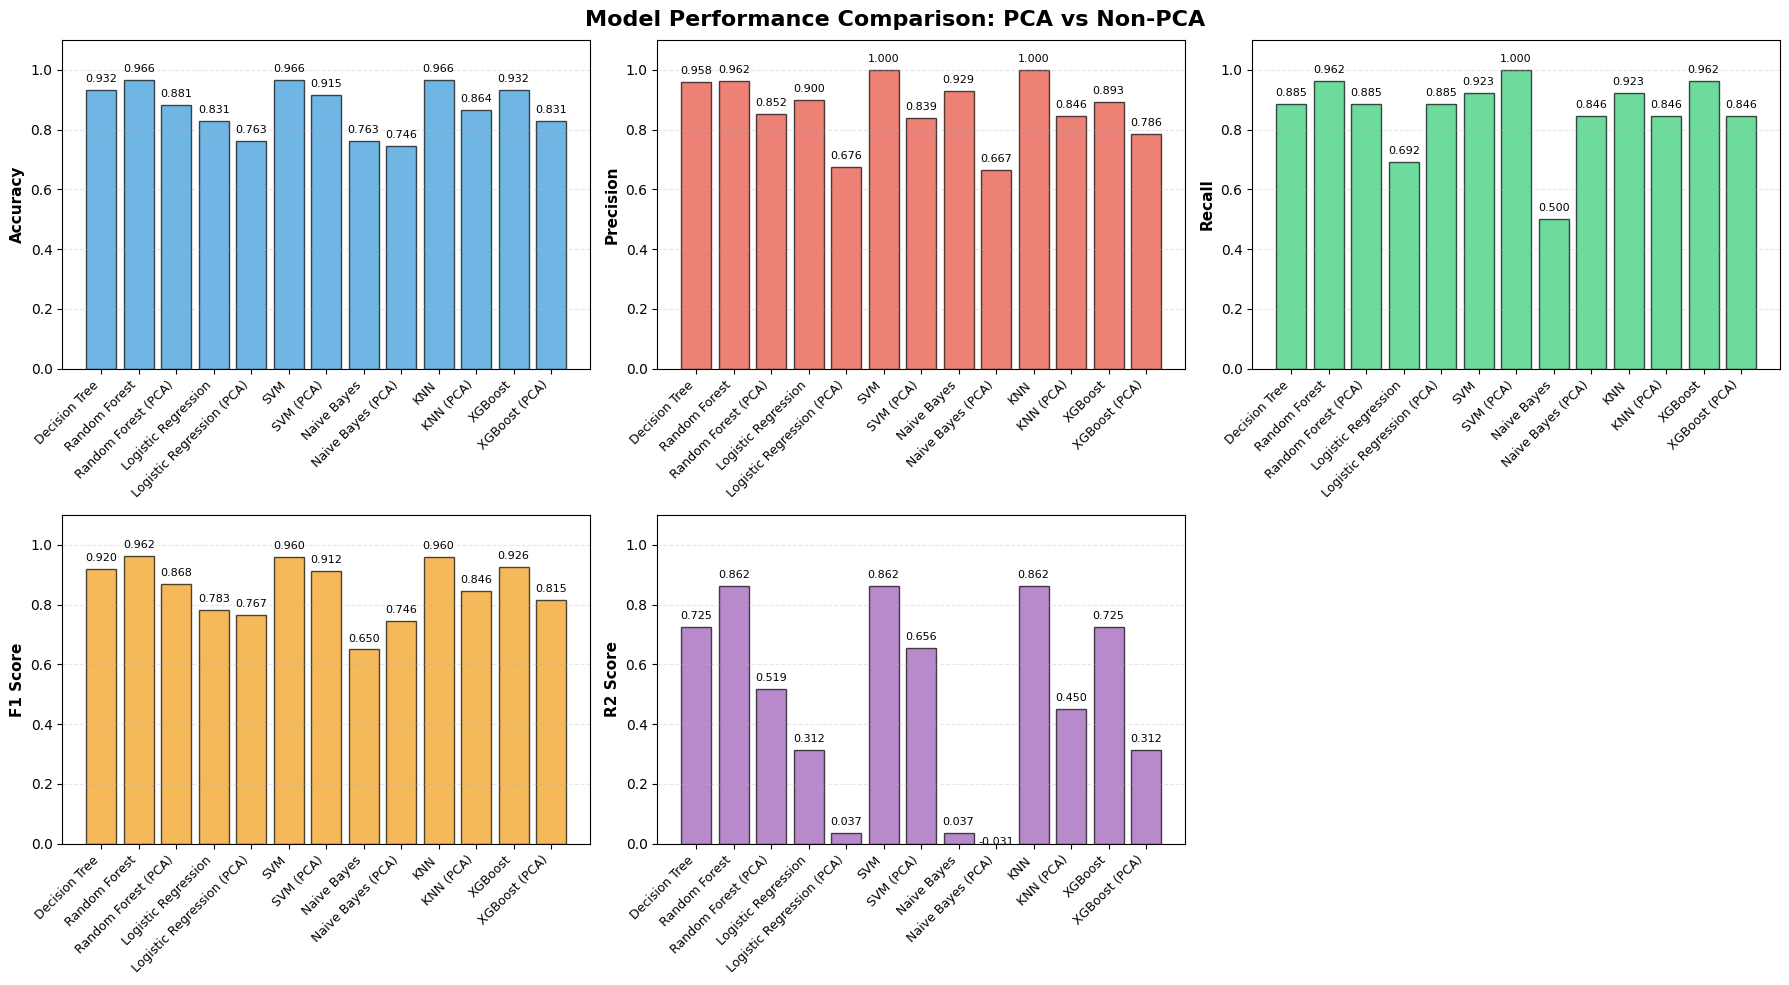


KEY INSIGHTS:
1. Models with (PCA) have reduced feature space but may show different performance
2. Compare each model's performance with and without PCA


In [ ]:
# ============================================
# COMPREHENSIVE MODEL COMPARISON: PCA vs NON-PCA
# ============================================
print("="*80)
print("MODEL COMPARISON: PCA vs Non-PCA Performance")
print("="*80)

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, r2_score

# Create comprehensive comparison table for all 7 models
comparison_data = []

# 1. Decision Tree
comparison_data.append({
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(y_test, predDT),
    'Precision': precision_score(y_test, predDT),
    'Recall': recall_score(y_test, predDT),
    'F1 Score': f1_score(y_test, predDT),
    'R2 Score': r2_score(y_test, predDT)
})

# 2. Random Forest
comparison_data.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, predRFC),
    'Precision': precision_score(y_test, predRFC),
    'Recall': recall_score(y_test, predRFC),
    'F1 Score': f1_score(y_test, predRFC),
    'R2 Score': r2_score(y_test, predRFC)
})

comparison_data.append({
    'Model': 'Random Forest (PCA)',
    'Accuracy': accuracy_score(y_test_pca, predRFC_pca),
    'Precision': precision_score(y_test_pca, predRFC_pca),
    'Recall': recall_score(y_test_pca, predRFC_pca),
    'F1 Score': f1_score(y_test_pca, predRFC_pca),
    'R2 Score': r2_score(y_test_pca, predRFC_pca)
})

# 3. Logistic Regression
comparison_data.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, predlog),
    'Precision': precision_score(y_test, predlog),
    'Recall': recall_score(y_test, predlog),
    'F1 Score': f1_score(y_test, predlog),
    'R2 Score': r2_score(y_test, predlog)
})

comparison_data.append({
    'Model': 'Logistic Regression (PCA)',
    'Accuracy': accuracy_score(y_test_pca, predlog_pca),
    'Precision': precision_score(y_test_pca, predlog_pca),
    'Recall': recall_score(y_test_pca, predlog_pca),
    'F1 Score': f1_score(y_test_pca, predlog_pca),
    'R2 Score': r2_score(y_test_pca, predlog_pca)
})

# 4. SVM
comparison_data.append({
    'Model': 'SVM',
    'Accuracy': accuracy_score(y_test, predSVC),
    'Precision': precision_score(y_test, predSVC),
    'Recall': recall_score(y_test, predSVC),
    'F1 Score': f1_score(y_test, predSVC),
    'R2 Score': r2_score(y_test, predSVC)
})

comparison_data.append({
    'Model': 'SVM (PCA)',
    'Accuracy': accuracy_score(y_test_pca, predSVC_pca),
    'Precision': precision_score(y_test_pca, predSVC_pca),
    'Recall': recall_score(y_test_pca, predSVC_pca),
    'F1 Score': f1_score(y_test_pca, predSVC_pca),
    'R2 Score': r2_score(y_test_pca, predSVC_pca)
})

# 5. Naive Bayes
comparison_data.append({
    'Model': 'Naive Bayes',
    'Accuracy': accuracy_score(y_test, predgnb),
    'Precision': precision_score(y_test, predgnb),
    'Recall': recall_score(y_test, predgnb),
    'F1 Score': f1_score(y_test, predgnb),
    'R2 Score': r2_score(y_test, predgnb)
})

comparison_data.append({
    'Model': 'Naive Bayes (PCA)',
    'Accuracy': accuracy_score(y_test_pca, predgnb_pca),
    'Precision': precision_score(y_test_pca, predgnb_pca),
    'Recall': recall_score(y_test_pca, predgnb_pca),
    'F1 Score': f1_score(y_test_pca, predgnb_pca),
    'R2 Score': r2_score(y_test_pca, predgnb_pca)
})

# 6. KNN
comparison_data.append({
    'Model': 'KNN',
    'Accuracy': accuracy_score(y_test, predKNN),
    'Precision': precision_score(y_test, predKNN),
    'Recall': recall_score(y_test, predKNN),
    'F1 Score': f1_score(y_test, predKNN),
    'R2 Score': r2_score(y_test, predKNN)
})

comparison_data.append({
    'Model': 'KNN (PCA)',
    'Accuracy': accuracy_score(y_test_pca, predKNN_pca),
    'Precision': precision_score(y_test_pca, predKNN_pca),
    'Recall': recall_score(y_test_pca, predKNN_pca),
    'F1 Score': f1_score(y_test_pca, predKNN_pca),
    'R2 Score': r2_score(y_test_pca, predKNN_pca)
})

# 7. XGBoost
comparison_data.append({
    'Model': 'XGBoost',
    'Accuracy': accuracy_score(y_test, predXGB),
    'Precision': precision_score(y_test, predXGB),
    'Recall': recall_score(y_test, predXGB),
    'F1 Score': f1_score(y_test, predXGB),
    'R2 Score': r2_score(y_test, predXGB)
})

comparison_data.append({
    'Model': 'XGBoost (PCA)',
    'Accuracy': accuracy_score(y_test_pca, predXGB_pca),
    'Precision': precision_score(y_test_pca, predXGB_pca),
    'Recall': recall_score(y_test_pca, predXGB_pca),
    'F1 Score': f1_score(y_test_pca, predXGB_pca),
    'R2 Score': r2_score(y_test_pca, predXGB_pca)
})

# Create DataFrame
comparison_df = pd.DataFrame(comparison_data)

# Display the table
print("\n")
display(comparison_df)

# Also display with better formatting
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
print(comparison_df.to_string(index=False))

# Create a visual comparison plot
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Performance Comparison: PCA vs Non-PCA', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'R2 Score']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

# Plot each metric
for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]

    # Get data for this metric
    models = comparison_df['Model'].values
    values = comparison_df[metric].values

    # Create bar plot
    bars = ax.bar(range(len(models)), values, color=colors[idx], alpha=0.7, edgecolor='black')

    # Customize plot
    ax.set_ylabel(metric, fontsize=11, fontweight='bold')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
    ax.set_ylim([0, 1.1])
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Add value labels on bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# Remove the empty subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("KEY INSIGHTS:")
print("="*80)
print("1. Models with (PCA) have reduced feature space but may show different performance")
print("2. Compare each model's performance with and without PCA")
print("="*80)


Here we can see that PCA has actually hurt every model and that is because the dataset is not very big. PCA thrives when we have large datasets that are overfitting so we do dimensionality reduction on it.
PCA is supposed to improve linear models like we have knn,svm,logistic and naive bayes but while PCA reduces the dimensionality, there is also loss of meaningful information. whenever we use PCA there is always loss of information, we can't retain 100% of the information.